## Imports

In [2]:
import os, pickle
import sys
import pandas as pd
import numpy as np
import torch
from pathlib import Path
import numpy as np
import logging
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import seaborn as sns
import scanpy as sc
import muon as mu

logging.basicConfig(level=logging.INFO, format='%(levelname)s - %(message)s')

PROJECT_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/TETHER")
DATA_DIR = PROJECT_DIR / "cached_data"
CHKPT_DIR = PROJECT_DIR / "checkpoints"
RESULT_DIR = PROJECT_DIR / "testing_results"

output_dir = PROJECT_DIR / "mouse_development_testing"

sys.path.append(str(PROJECT_DIR))

import warnings

if torch.cuda.is_available():
    device = torch.device("cuda")
    logging.info(f"Using GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.set_float32_matmul_precision("high")
else:
    device = torch.device("cpu")
    logging.info("Using CPU")

warnings.filterwarnings(
    "ignore",
    message="You are using `torch.load` with `weights_only=False`.*",
    category=FutureWarning,
)

font_path = PROJECT_DIR / "fonts" / "Arial.ttf"

fm.fontManager.addfont(font_path)
arial_font = fm.FontProperties(fname=font_path).get_name()

mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = [arial_font, "Helvetica", "Liberation Sans", "DejaVu Sans"]

logging.info(f"Using font: {arial_font}")

rng = np.random.default_rng()

INFO - Using CPU
INFO - Using font: Arial


## Labeling Cell Lineages


### Load Muon Data
Does the model, when trained using hepatocyte data, correctly identify lineage-specific signaling in mouse embryonic cells? To test this, I first need to load in the muon h5mu file for the sample. We will re-normalize the raw counts for getting the cell lineages.

In [3]:
def load_muon_data(cell_type, sample_name):
    mudata_path = Path(f"/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/sample_input_data/{cell_type}/{sample_name}/multiome_processed.h5mu")
    
    mudata = mu.read_h5mu(mudata_path)
    return mudata

e85_expression = load_muon_data("mESC", "E8.5_rep1")
rna = e85_expression["rna"]
rna_de = rna.copy()

# Re-normalize the raw counts
rna_de.X = rna_de.layers["counts"].copy()
sc.pp.normalize_total(rna_de,target_sum=1e4)
# sc.pp.log1p(rna_de)

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


### Rank gene groups

Next we will get the marker genes between the groups, based on the `leiden` attribute.

In [4]:
sc.tl.rank_genes_groups(
    rna_de,
    groupby="leiden",
    reference="rest",
    method="wilcoxon",
    use_raw=False,
    pts=True,
    key_added="leiden_markers"
)

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_g

In [5]:
all_clusters = rna_de.obs["leiden"].unique().tolist()

# Get the top 15 markers per cluster
summary = {}
for cluster in all_clusters:
    df = sc.get.rank_genes_groups_df(
        rna_de,
        group=cluster,
        key="leiden_markers"
    ).copy()
    
    # Only return significant marker genes
    df = df[
        (df["scores"] > 0) &
        (df["pvals_adj"] < 0.05)
    ]

    # Set a specificity score based on how expressed the gene is 
    # in the cluster vs the rest of the cells
    df["specificity"] = (
        df["pct_nz_group"] - df["pct_nz_reference"]
    )

    # Combine statistical rank and specificity
    df = df.sort_values(
        ["scores", "specificity"],
        ascending=False
    )

    summary[cluster] = df["names"].head(15).tolist()
    
for cluster, genes in summary.items():
    print(f"Cluster {cluster}: {', '.join(genes)}")

Cluster 0: Cubn, Apob, Amn, Apoe, Rbp4, Apoc2, Ttr, Apoa1, Lgmn, Dab2, Myo6, Trf, Apom, Ctsb, Afp
Cluster 2: Kdr, Fli1, Egfl7, Plvap, Flt1, Tek, Vav3, Elk3, Shank3, Rhoj, Flt4, Igfbp4, Ramp2, Arap3, Eng
Cluster 3: Fbn2, Cdh11, Col26a1, Foxp2, Fst, Vcan, Aff3, Ebf1, Ebf2, Col23a1, Fzd2, Ank3, Nr2f2, Marcks, Colec12
Cluster 6: Epha5, Nr6a1, Ncam1, Sema3e, Mllt3, Hoxaas3, Dlg1, Sema6a, Greb1, Tmem132c, Ptk7, Hoxc4, Sema3a, Dcc, Hoxb3
Cluster 7: Hbb-bh1, Hba-x, Hba-a1, Hba-a2, Abcb10, Reln, Slc25a21, Sptb, Slc25a37, Gpx1, Blvrb, Ank1, Car2, Snca, Cpox
Cluster 9: Pmp22, Ahnak, Dlk1, Nrp1, Col1a2, Ece1, Serpinh1, Igfbp2, Igf2, Slc2a1, Tmem108, Col5a2, Smoc2, Stard8, Mest
Cluster 5: Adgrv1, Ptn, Efna5, Tenm4, Mast4, Robo1, Rmst, Sox11, Fzd3, Qk, Dcc, Ctnna2, Rfx3, Nr6a1, Ank2
Cluster 10: Lef1, Pcdh19, Dll3, Dll1, Rspo3, Laptm4b, Smc6, Smoc1, Tmem132c, Rnf213, Epha4, Fn1, Kif26b, Greb1l, Mllt3
Cluster 11: Wnt6, Slc2a3, Bcam, Frem2, Dag1, Npnt, Epcam, Spint2, Ptprf, Hapln1, Cdh3, Esrp1, F11r, L

### Assign cell lineages based on the marker genes

In [6]:
cluster_to_lineage = {
    "0":  "Endothelial",
    "1":  "Neural ectoderm",
    "2":  "Presomitic mesoderm",
    "3":  "Nascent/posterior mesoderm",
    "4":  "Cranial/pharyngeal mesoderm",
    "5":  "Primitive erythroid",
    "6":  "Extraembryonic mesoderm",
    "7":  "Amniotic/surface ectoderm",
    "8":  "Surface/placodal ectoderm",
    "9":  "Anterior neural ectoderm",
    "10": "Somitic/paraxial mesoderm",
    "11": "Trophoblast/extraembryonic ectoderm",
    "12": "Primitive erythroid",
    "13": "Definitive/gut endoderm",
    "14": "Posterior extraembryonic mesoderm",
    "15": "Lateral plate mesoderm",
    "16": "Midbrain-hindbrain neural ectoderm",
    "17": "Allantoic mesoderm",
    "18": "Parietal endoderm",
    "19": "Neural tube",
    "20": "NMP",
    "21": "Ventral spinal cord",
    "22": "Neural crest",
    "23": "Visceral/yolk-sac endoderm",
    "24": "Cardiomyocyte",
}

cluster_to_broad_lineage = {
    "0":  "Mesoderm",          # Endothelial
    "1":  "Ectoderm",          # Neural ectoderm
    "2":  "Mesoderm",          # Presomitic mesoderm
    "3":  "Mesoderm",          # Nascent/posterior mesoderm
    "4":  "Mesoderm",          # Cranial/pharyngeal mesoderm
    "5":  "Hematopoietic",     # Primitive erythroid
    "6":  "Extraembryonic",    # Extraembryonic mesoderm
    "7":  "Ectoderm",          # Amniotic/surface ectoderm
    "8":  "Ectoderm",          # Surface/placodal ectoderm
    "9":  "Ectoderm",          # Anterior neural ectoderm
    "10": "Mesoderm",          # Somitic/paraxial mesoderm
    "11": "Extraembryonic",    # Trophoblast/extraembryonic ectoderm
    "12": "Hematopoietic",     # Primitive erythroid
    "13": "Endoderm",          # Definitive/gut endoderm
    "14": "Extraembryonic",    # Posterior extraembryonic mesoderm
    "15": "Mesoderm",          # Lateral plate mesoderm
    "16": "Ectoderm",          # Midbrain-hindbrain neural ectoderm
    "17": "Extraembryonic",    # Allantoic mesoderm
    "18": "Extraembryonic",    # Parietal endoderm
    "19": "Ectoderm",          # Neural tube
    "20": "Ectoderm",          # NMP
    "21": "Ectoderm",          # Ventral spinal cord
    "22": "Ectoderm",          # Neural crest
    "23": "Extraembryonic",    # Visceral/yolk-sac endoderm
    "24": "Mesoderm",          # Cardiomyocyte
}

rna.obs["fine_lineage"] = (
    rna.obs["leiden"]
    .astype(str)
    .map(cluster_to_lineage)
)

rna.obs["broad_lineage"] = (
    rna.obs["leiden"]
    .astype(str)
    .map(cluster_to_broad_lineage)
)

rna.obs["fine_lineage"] = pd.Categorical(rna.obs["fine_lineage"])
rna.obs["broad_lineage"] = pd.Categorical(rna.obs["broad_lineage"])

### UMAP of labeled cell lineages

#### Fine Lineages

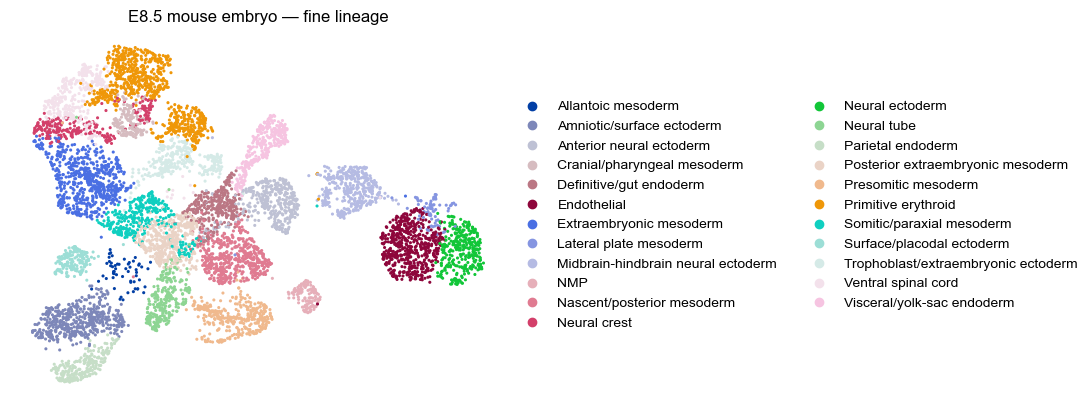

In [7]:
rna.obs[["leiden", "fine_lineage"]].drop_duplicates().sort_values("leiden")

sc.pl.umap(
    rna,
    color="fine_lineage",
    legend_loc="right margin",
    frameon=False,
    size=20,
    title="E8.5 mouse embryo — fine lineage"
)

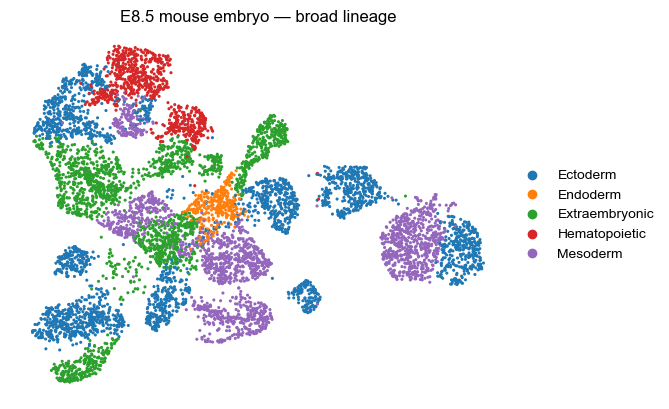

In [8]:
rna.obs[["leiden", "broad_lineage"]].drop_duplicates().sort_values("leiden")

sc.pl.umap(
    rna,
    color="broad_lineage",
    legend_loc="right margin",
    frameon=False,
    size=20,
    title="E8.5 mouse embryo — broad lineage"
)

### Dot Plot of Marker Genes by Broad Category

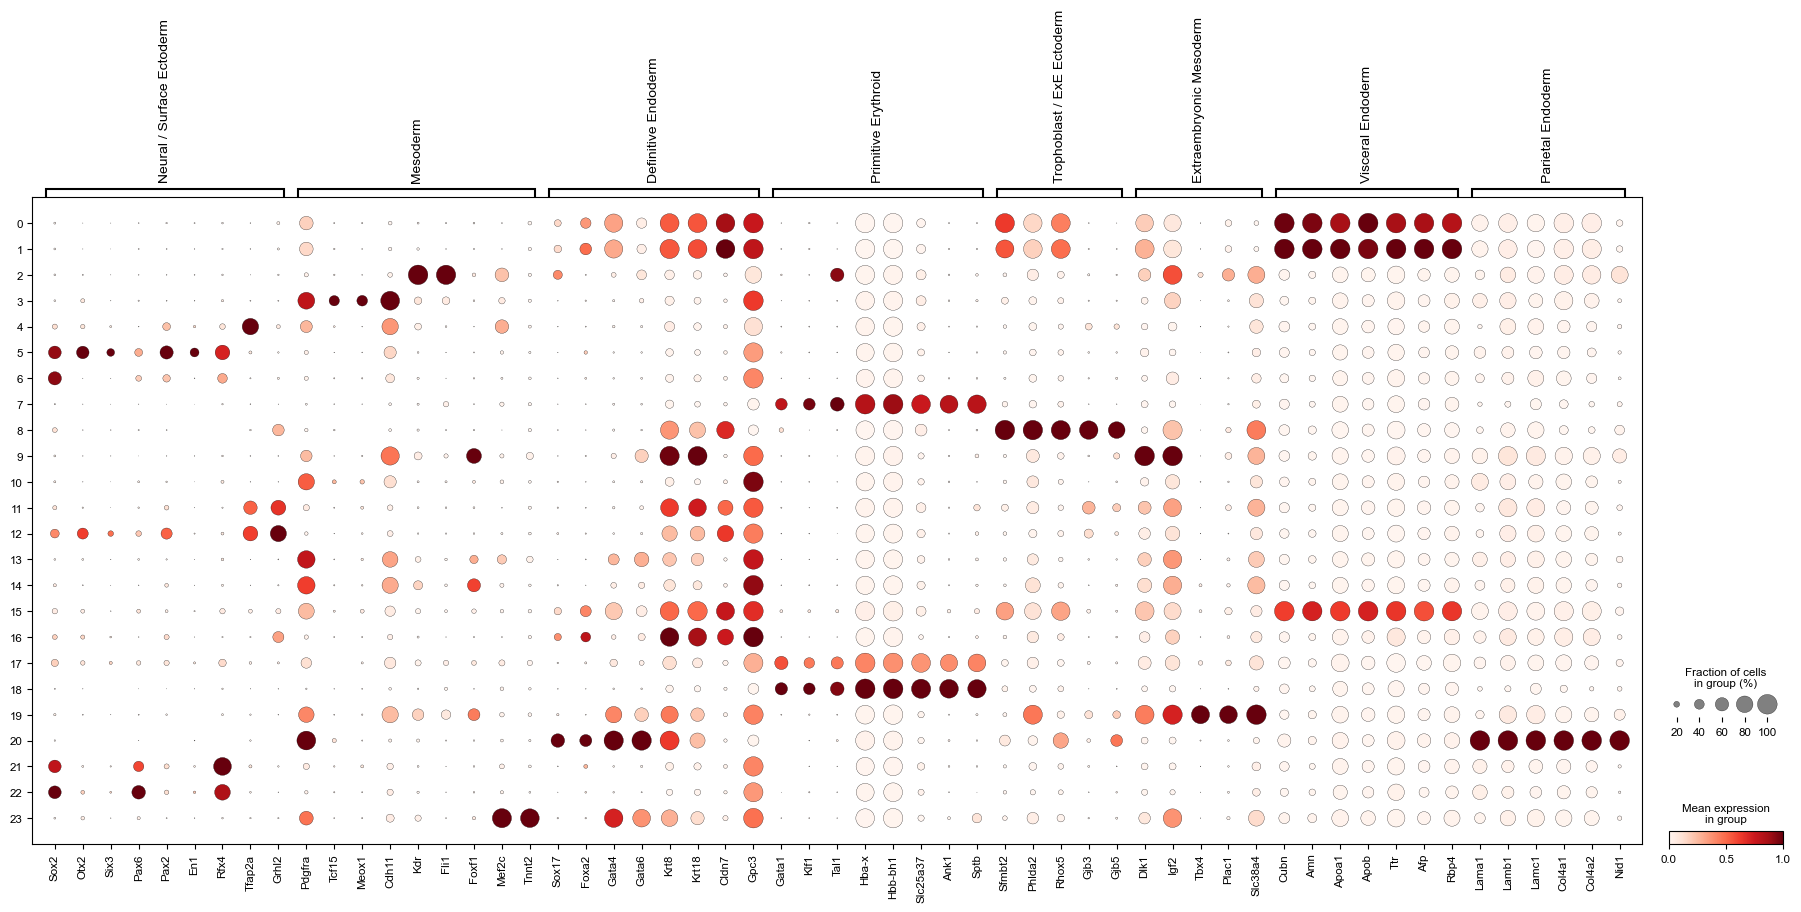

In [9]:
marker_groups = {
    "Neural / Surface Ectoderm": [
        "Sox2", "Otx2", "Six3", "Pax6",
        "Pax2", "En1", "Rfx4",
        "Tfap2a", "Grhl2",
    ],

    "Mesoderm": [
        "Pdgfra", "Tcf15", "Meox1",
        "Cdh11", "Kdr", "Fli1",
        "Foxf1", "Mef2c", "Tnnt2",
    ],

    "Definitive Endoderm": [
        "Sox17", "Foxa2", "Gata4", "Gata6",
        "Krt8", "Krt18", "Cldn7", "Gpc3",
    ],

    "Primitive Erythroid": [
        "Gata1", "Klf1", "Tal1",
        "Hba-x", "Hbb-bh1", "Slc25a37",
        "Ank1", "Sptb",
    ],

    "Trophoblast / ExE Ectoderm": [
        "Sfmbt2", "Phlda2", "Rhox5",
        "Gjb3", "Gjb5",
    ],

    "Extraembryonic Mesoderm": [
        "Dlk1", "Igf2", "Tbx4",
        "Plac1", "Slc38a4",
    ],

    "Visceral Endoderm": [
        "Cubn", "Amn", "Apoa1",
        "Apob", "Ttr", "Afp", "Rbp4",
    ],

    "Parietal Endoderm": [
        "Lama1", "Lamb1", "Lamc1",
        "Col4a1", "Col4a2", "Nid1",
    ],
}

# Drop unused Leiden categories
rna_de.obs["leiden"] = (
    rna_de.obs["leiden"]
    .cat.remove_unused_categories()
)

# Remove genes absent from the dataset
marker_groups = {
    group: [gene for gene in genes if gene in rna_de.var_names]
    for group, genes in marker_groups.items()
}

# Remove empty marker groups
marker_groups = {
    group: genes
    for group, genes in marker_groups.items()
    if len(genes) > 0
}

# Order clusters numerically
clusters_of_interest = [
    str(i)
    for i in range(25)
    if str(i) in rna_de.obs["leiden"].cat.categories
]

sc.pl.dotplot(
    rna_de,
    marker_groups,
    groupby="leiden",
    categories_order=clusters_of_interest,
    standard_scale="var",
    swap_axes=False,
    use_raw=False,
)

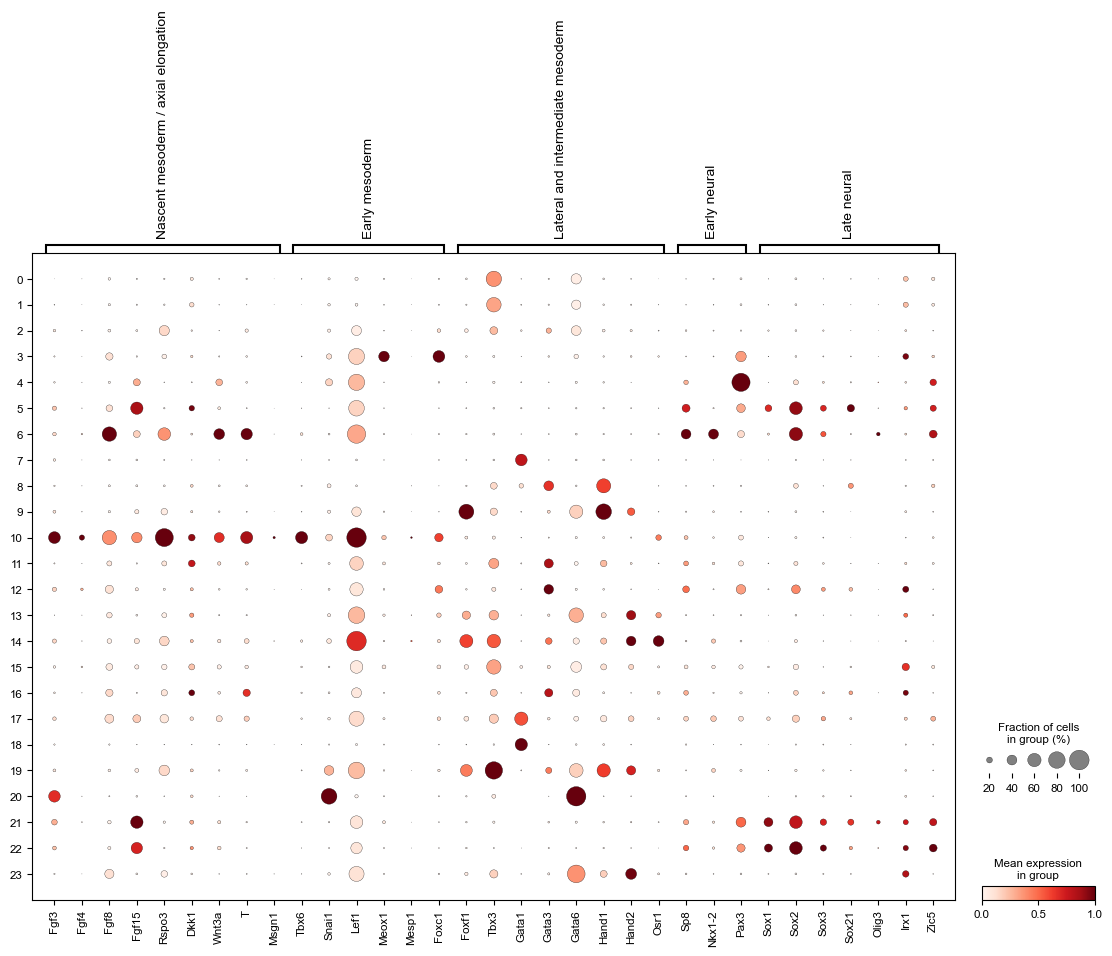

In [10]:
marker_groups = {
    "Nascent mesoderm / axial elongation": [
        "Fgf3",
        "Fgf4",
        "Fgf8",
        "Fgf15",
        "Rspo3",
        "Dkk1",
        "Wnt3a",
        "T",
        "Msgn1",
    ],

    "Early mesoderm": [
        "Tbx6",
        "Snai1",
        "Lef1",
        "Meox1",
        "Mesp1",
        "Foxc1",
    ],

    "Lateral and intermediate mesoderm": [
        "Foxf1",
        "Tbx3",
        "Gata1",
        "Gata3",
        "Gata6",
        "Hand1",
        "Hand2",
        "Osr1",
    ],

    "Early neural": [
        "Sp8",
        "Nkx1-2",
        "Pax3",
    ],

    "Late neural": [
        "Sox1",
        "Sox2",
        "Sox3",
        "Sox21",
        "Olig3",
        "Irx1",
        "Zic5",
    ],
}

# Drop unused Leiden categories
rna_de.obs["leiden"] = (
    rna_de.obs["leiden"]
    .cat.remove_unused_categories()
)

# Remove genes absent from the dataset
marker_groups = {
    group: [gene for gene in genes if gene in rna_de.var_names]
    for group, genes in marker_groups.items()
}

# Remove empty marker groups
marker_groups = {
    group: genes
    for group, genes in marker_groups.items()
    if len(genes) > 0
}

# Order clusters numerically
clusters_of_interest = [
    str(i)
    for i in range(25)
    if str(i) in rna_de.obs["leiden"].cat.categories
]

sc.pl.dotplot(
    rna_de,
    marker_groups,
    groupby="leiden",
    categories_order=clusters_of_interest,
    standard_scale="var",
    swap_axes=False,
    use_raw=False,
)

#### NMP Marker Genes

**Group I - NMP marker genes:**
- *T*, *Sox2*,  *Rspo3*, *Fgf8*, *Wnt3a*,  *Msgn1*, *Fgf3*, *Fgf4*, *Fgf8*, *Fgf15*, *Rspo3*, *Dkk1*
- No expression of Tbx6 or other lineage-specific control genes from groups II-V

**Group II - Early mesoderm marker genes:**
- *Tbx6*, *Snai1*, *Lef1*, *Meox1*, *Mesp1*, *Foxc1*,

**Group III - Lateral and intermediate mesoderm control markers:**
- *Foxf1*, *Tbx3*, *Gata1*, *Gata3*, *Gata6*, *Hand1*, *Hand2*, and *Osr1*
- Low expression in T+/Sox2+ cells
- High expression in T+ cells

**Group IV - Early neural control markers:**
- *Sp8*, *Nkx1-2*, and *Pax3*
- High expression in T+/Sox2+ cells

**Group V - Late neural control markers:**
- *Sox1*, *Sox3*, *Sox21*, *Olig3*, *Irx1*, and *Zic5*
- High expression in Sox2+ cells
- Low expression in T+ cells

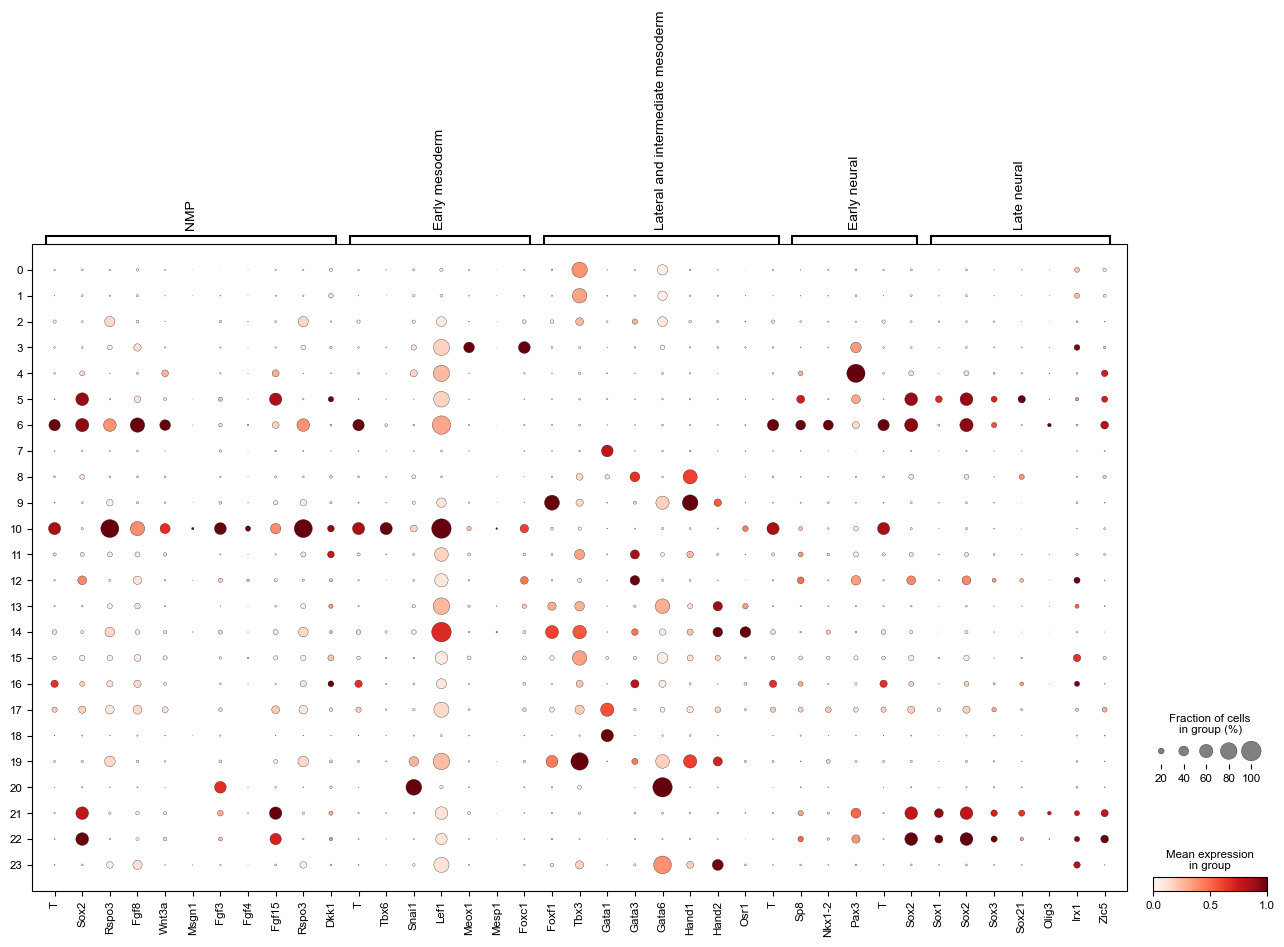

In [11]:
nmp_marker_groups = {
    "NMP": [
        "T",
        "Sox2",
        "Rspo3",
        "Fgf8",
        "Wnt3a",
        "Msgn1",
        "Fgf3",
        "Fgf4",
        "Fgf15",
        "Rspo3",
        "Dkk1",
    ],
    "Early mesoderm": [
        "T",
        "Tbx6",
        "Snai1",
        "Lef1",
        "Meox1",
        "Mesp1",
        "Foxc1",
    ],

    "Lateral and intermediate mesoderm": [
        "Foxf1",
        "Tbx3",
        "Gata1",
        "Gata3",
        "Gata6",
        "Hand1",
        "Hand2",
        "Osr1",
        "T"
    ],

    "Early neural": [
        "Sp8",
        "Nkx1-2",
        "Pax3",
        "T",
        "Sox2"
    ],

    "Late neural": [
        "Sox1",
        "Sox2",
        "Sox3",
        "Sox21",
        "Olig3",
        "Irx1",
        "Zic5",
    ],
}

# Drop unused Leiden categories
rna_de.obs["leiden"] = (
    rna_de.obs["leiden"]
    .cat.remove_unused_categories()
)

# Remove genes absent from the dataset
nmp_marker_groups = {
    group: [gene for gene in genes if gene in rna_de.var_names]
    for group, genes in nmp_marker_groups.items()
}

# Remove empty marker groups
nmp_marker_groups = {
    group: genes
    for group, genes in nmp_marker_groups.items()
    if len(genes) > 0
}

# Order clusters numerically
clusters_of_interest = [
    str(i)
    for i in range(25)
    if str(i) in rna_de.obs["leiden"].cat.categories
]

sc.pl.dotplot(
    rna_de,
    nmp_marker_groups,
    groupby="leiden",
    categories_order=clusters_of_interest,
    standard_scale="var",
    swap_axes=False,
    use_raw=False,
)

Cluster 20 has strong expression of NMP/posterior axial progenitor genes. Clusters 19 and 21 have strong expression of neural committment genes. From the previous marker genes, cluster 21 has strong evidence for ventralization due to Nkx6-1 and Hedgehog-response genes such as Ptch1. Cluster 19 is likely spinal cord / neural tube progenitor cells. 

### Plot of NMP differentiation

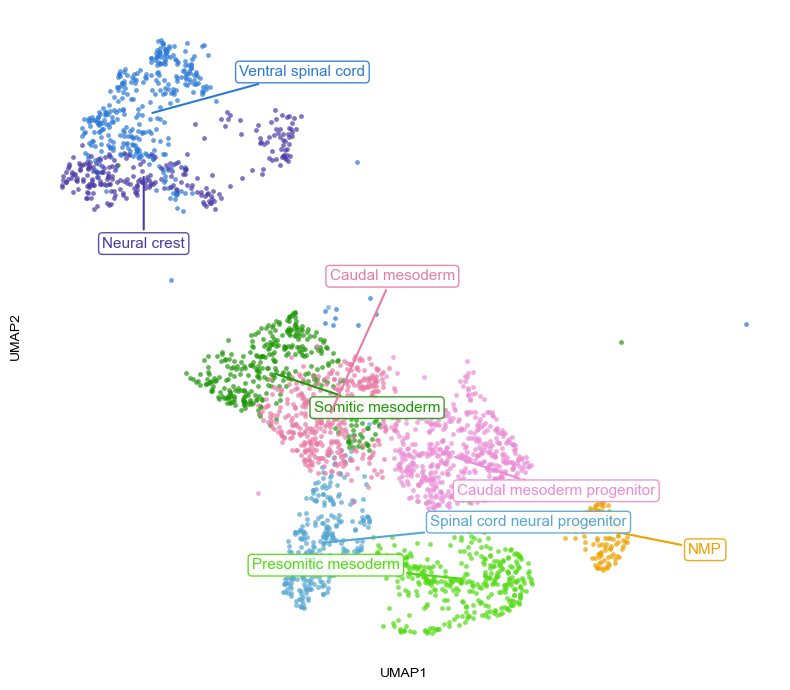

In [12]:
developmental_cluster_map = {
    "20": "NMP",
    "19": "Spinal cord neural progenitor",
    "21": "Ventral spinal cord",

    "2":  "Presomitic mesoderm",
    "10": "Somitic mesoderm",

    "3":  "Caudal mesoderm progenitor",
    "14": "Caudal mesoderm",

    "22": "Neural crest",
}

lineage_cols = {
    "NMP": "#eda100",
    "Spinal cord neural progenitor": "#55a6d1",
    "Ventral spinal cord": "#2a78d6",
    "Presomitic mesoderm": "#51db11",
    "Somitic mesoderm": "#21970a",
    "Caudal mesoderm progenitor": "#ea8cd6",
    "Caudal mesoderm": "#e87ba4",
    "Neural crest": "#4a3aa7",
}

# Clusters to include
clusters_to_plot = list(developmental_cluster_map.keys())

# Subset cells
rna_dev = rna_de[
    rna_de.obs["leiden"].astype(str).isin(clusters_to_plot)
].copy()

# Assign developmental lineage
rna_dev.obs["developmental_lineage"] = (
    rna_dev.obs["leiden"]
    .astype(str)
    .map(developmental_cluster_map)
)

# UMAP coordinates
umap = rna_dev.obsm["X_umap"]

fig, ax = plt.subplots(figsize=(8, 7))

# Plot each developmental lineage separately
for lineage, color in lineage_cols.items():

    mask = (
        rna_dev.obs["developmental_lineage"] == lineage
    ).to_numpy()

    ax.scatter(
        umap[mask, 0],
        umap[mask, 1],
        s=12,
        alpha=0.7,
        c=color,
        label=lineage.replace("_", " "),
        linewidths=0,
    )

# Add developmental lineage labels with lines pointing
# to the median UMAP position of each lineage
umap_label_offsets = {
    "NMP": (75, -15),
    "Spinal cord neural progenitor": (150, 15),
    "Ventral spinal cord": (110, 30),
    "Presomitic mesoderm": (-100, 10),
    "Somitic mesoderm": (75, -25),
    "Caudal mesoderm progenitor": (75, -25),
    "Caudal mesoderm": (45, 100),
    "Neural crest": (0, -50),
}

for lineage, color in lineage_cols.items():

    mask = (
        rna_dev.obs["developmental_lineage"] == lineage
    ).to_numpy()

    if not mask.any():
        continue

    # Median location of all cells belonging to this lineage
    x = np.median(umap[mask, 0])
    y = np.median(umap[mask, 1])

    offset = umap_label_offsets.get(lineage, (30, 30))

    ax.annotate(
        lineage.replace("_", " "),
        xy=(x, y),                  # point the line to this location
        xytext=offset,              # label offset in points
        textcoords="offset points",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color=color,
        arrowprops=dict(
            arrowstyle="-",
            color=color,
            linewidth=1.5,
        ),
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor=color,
            alpha=0.9,
        ),
    )

ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")

# ax.legend(
#     title="Developmental lineage",
#     bbox_to_anchor=(1.02, 1),
#     loc="upper left",
#     frameon=False,
# )

ax.set_xticks([])
ax.set_yticks([])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

### ForceAtlas2 NMP Differentiation Trajectory from kNN Connectivities

In [13]:
import networkx as nx

# subset data to developmental lineage clusters
clusters_to_plot = list(developmental_cluster_map.keys())

rna_dev = rna_de[
    rna_de.obs["leiden"].astype(str).isin(clusters_to_plot)
].copy()

rna_dev.obs["developmental_lineage"] = (
    rna_dev.obs["leiden"]
    .astype(str)
    .map(developmental_cluster_map)
)

# Get the kNN connectivities
connectivities = (
    rna_dev.obsp["connectivities"]
    .tocsr()
    .copy()
)

# Make symmetric and remove self-edges
connectivities = connectivities.maximum(connectivities.T)

connectivities.setdiag(0)
connectivities.eliminate_zeros()

# Convert to NetworkX
G = nx.from_scipy_sparse_array(
    connectivities,
    create_using=nx.Graph,
    edge_attribute="weight",
)


In [14]:
# Run ForceAtlas2
pos = nx.forceatlas2_layout(
    G,
    max_iter=500,
    scaling_ratio=2.0,
    gravity=1.0,
    weight="weight",
    seed=42,
)

# Convert dictionary to an array matching rna_dev.obs order
forceatlas = np.array([
    pos[i]
    for i in range(rna_dev.n_obs)
])

# Save in AnnData
rna_dev.obsm["X_forceatlas2"] = forceatlas

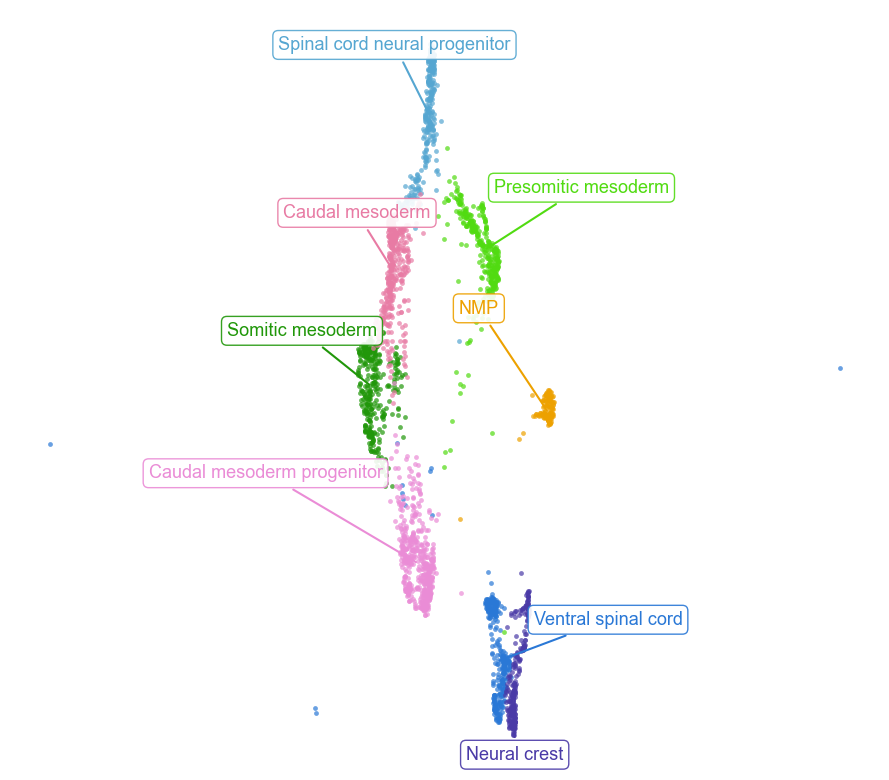

In [15]:
# -------------------------------------------------------
# 5. Plot ForceAtlas2 layout
# -------------------------------------------------------

coords = rna_dev.obsm["X_forceatlas2"]

fig, ax = plt.subplots(figsize=(9, 8))

for lineage, color in lineage_cols.items():

    mask = (
        rna_dev.obs["developmental_lineage"] == lineage
    ).to_numpy()

    ax.scatter(
        coords[mask, 0],
        coords[mask, 1],
        s=12,
        alpha=0.7,
        c=color,
        linewidths=0,
        label=lineage.replace("_", " "),
    )

# -------------------------------------------------------
# 6. Add lineage labels
# -------------------------------------------------------

force_plot_label_offsets = {
    "NMP": (-50, 75),
    "Spinal cord neural progenitor": (-25, 50),
    "Ventral spinal cord": (80, 30),
    "Presomitic mesoderm": (70, 45),
    "Somitic mesoderm": (-50, 40),
    "Caudal mesoderm progenitor": (-110, 65),
    "Caudal mesoderm": (-25, 40),
    "Neural crest": (0, -50),
}

for lineage, color in lineage_cols.items():

    mask = (
        rna_dev.obs["developmental_lineage"] == lineage
    ).to_numpy()

    if not mask.any():
        continue

    # Median ForceAtlas2 position
    x = np.median(coords[mask, 0])
    y = np.median(coords[mask, 1])

    ax.annotate(
        lineage.replace("_", " "),
        xy=(x, y),
        xytext=force_plot_label_offsets.get(lineage, (30, 30)),
        textcoords="offset points",
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
        color=color,
        arrowprops=dict(
            arrowstyle="-",
            color=color,
            linewidth=1.5,
        ),
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor=color,
            alpha=0.9,
            
        ),
    )


ax.set_xlabel("")
ax.set_ylabel("")

ax.set_xticklabels([])
ax.set_yticklabels([])

ax.set_xticks([])
ax.set_yticks([])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

In [16]:
import scipy.sparse as sp

genes = ["T", "Sox2", "Tbx6", "Msgn1"]

for gene in genes:
    if gene not in rna_dev.var_names:
        continue

    x = rna_dev[:, gene].X
    v = x.toarray().ravel() if sp.issparse(x) else np.asarray(x).ravel()

    df = pd.DataFrame({
        "expression": v,
        "lineage": rna_dev.obs["developmental_lineage"].values,
    })

    summary = (
        df.groupby("lineage", observed=True)
        .agg(
            mean_expression=("expression", "mean"),
            pct_expressing=("expression", lambda x: (x > 0).mean()),
        )
        .sort_values("mean_expression", ascending=False)
    )

    print(f"\n===== {gene} =====")
    print(summary.round(3).to_string())


===== T =====
                               mean_expression  pct_expressing
lineage                                                       
Somitic mesoderm                         1.606           0.529
Caudal mesoderm                          0.254           0.154
Presomitic mesoderm                      0.126           0.094
Ventral spinal cord                      0.066           0.032
Spinal cord neural progenitor            0.059           0.050
Caudal mesoderm progenitor               0.049           0.038
Neural crest                             0.035           0.024
NMP                                      0.020           0.008

===== Sox2 =====
                               mean_expression  pct_expressing
lineage                                                       
Neural crest                             1.520           0.564
Ventral spinal cord                      1.200           0.557
Caudal mesoderm                          0.119           0.087
Somitic mesoderm      

These lineage-specific gene expression patterns line up with the original paper's results

In [17]:
nmp_metacells = rna_dev.obs_names.to_list()
print(nmp_metacells)

['AAACAGCCACCTATAG-1', 'AAACAGCCATGGCCCA-1', 'AAACATGCAAAGGCCA-1', 'AAACATGCACTATGGC-1', 'AAACCGAAGTCTCACC-1', 'AAACCGCGTTGAGGTC-1', 'AAACGTACAGCCTTGG-1', 'AAAGCAAGTCAGTAAT-1', 'AAAGCAAGTGCCGCAA-1', 'AAAGCACCAACCTAAT-1', 'AAAGCACCACTAAGTT-1', 'AAAGCCGCAGCATGTC-1', 'AAAGCGGGTCGTTATC-1', 'AAAGGAGCATCTTGAG-1', 'AAAGGAGCATTGACAT-1', 'AAAGGCTCACTAAGAA-1', 'AAAGGTTAGGAACGGT-1', 'AAAGGTTAGTCGCTAG-1', 'AAATCCGGTCAATGTG-1', 'AAATCCGGTGGTGAGA-1', 'AAATGCCTCCGCCTCA-1', 'AAATGGCCAGAAATGC-1', 'AAATGGCCAGGAACCA-1', 'AAATGGCCATCACTTC-1', 'AACAAAGGTGAGCAAG-1', 'AACAAGCCATGAATAG-1', 'AACAGATAGCGTGCGT-1', 'AACAGATAGTAACCCG-1', 'AACAGATAGTTTGGGT-1', 'AACAGCAAGAATGACG-1', 'AACATCATCAATCTCT-1', 'AACATCATCTCCTCAA-1', 'AACCGCTCATAGACCC-1', 'AACCGCTCATCAGTAT-1', 'AACCGGCTCTTTAGGA-1', 'AACCTAATCCTGTTCA-1', 'AACCTAATCTAAATCG-1', 'AACCTAATCTCAATTC-1', 'AACCTCCTCCCTCAAC-1', 'AACCTTGCAATATAGG-1', 'AACCTTGCACACAATT-1', 'AACGCCCAGCAGCTAT-1', 'AACGCCCAGGAGGTTA-1', 'AACGCCCAGTTTAACG-1', 'AACGCTAGTAGGTGTC-1', 'AACTAGCT

## Hepatocyte Model Predictions for E8.5

A TETHER model was trained using data from `hepatocytes_1`. We will use it to make TF-TG predictions using the cells in the NMP trajectory. First, we will generate a file containing the cell barcodes for the NMP trajectory metacells.

In [18]:
# metacell_file = output_dir / "E8.5_rep1_NMP_metacells.txt"

# with open(metacell_file, "w") as file:
#     for metacell in nmp_metacells:
#         file.write(metacell)
#         file.write(",")

Next, we will generate a GRN using the NMP metacells using the `hepatocytes_1` trained model. 

`sbatch run_generate_hepatocyte_vs_nmp_grn.sh`

Once that finishes running, we can load in the predictions:

In [19]:
prediction_df = pd.read_csv(output_dir / "hepatocyte_model_vs_E8.5_rep1_NMP_metacell_GRN.csv", index_col=0)
prediction_df

,Source,Target,Score
0,ADNP,0610006L08RIK,0.158540
1,ADNP,0610009E02RIK,0.374138
2,ADNP,0610009L18RIK,0.267259
3,ADNP,0610012D04RIK,0.198981
4,ADNP,0610025J13RIK,0.207875
...,...,...,...
7464365,ZKSCAN1,ZYG11A,0.161708
7464366,ZKSCAN1,ZYG11B,0.440862
7464367,ZKSCAN1,ZYX,0.387765
7464368,ZKSCAN1,ZZEF1,0.309777


Next, we will filter the scores to only show the top 25 targets of each TF

In [20]:
top_tf_prediction_df = prediction_df.copy()
top_tf_prediction_df = (top_tf_prediction_df
                        .sort_values("Score", ascending=False)
                        .groupby("Source", sort=False)
                        .head(25)
                        .reset_index(drop=True)
                        )
top_tf_prediction_df

,Source,Target,Score
0,KLF4,PRTG,0.999781
1,KLF4,RERE,0.999717
2,KLF5,COL18A1,0.999610
3,KLF5,PLEKHA5,0.999604
4,KLF5,GPC3,0.999572
...,...,...,...
10745,E4F1,SPARC,0.082875
10746,E4F1,AIRN,0.081860
10747,E4F1,IFRD2,0.081384
10748,E4F1,HOXB8,0.080881


In [21]:
print(f"Number of TFs: {top_tf_prediction_df['Source'].nunique()}")
print(f"Number of predicted interactions: {len(top_tf_prediction_df)}")

Number of TFs: 430
Number of predicted interactions: 10750


In [22]:
num_interactions_per_target = (
top_tf_prediction_df.groupby("Target")
    .size()
    .reset_index(name="num_interactions")
    .sort_values("num_interactions", ascending=False)
)
num_interactions_per_target

,Target,num_interactions
1662,PBX3,139
1767,PODXL,130
1856,PTPN13,124
480,COL18A1,90
1412,MEIS2,76
...,...,...
44,4930596I21RIK,1
45,4930599N23RIK,1
35,4930453N24RIK,1
36,4930473H19RIK,1


Some of the targets are hubs for TF-TG interactions. We should take this into account to weight the TF-TG edge score by how specific the interaction is for the TF. We can use a simple IDF-like metric where the specificity is inversely related to the proportion of TFs targeting the TG.

$$\text{Specificity(TG)} = log\left(\frac{1 + N_{\text{TF}}}{1 + N_{\text{TFs predicting TG}}}\right)$$

> Note: The +1 added to the numerator and demoninator makes it so that the specificity can never become negative (previously possible if all TFs targeted a TG)

In [23]:
top_tf_prediction_adj_df = top_tf_prediction_df.copy()

num_tfs = top_tf_prediction_adj_df["Source"].nunique()

top_tf_prediction_adj_df["num_tfs_targeting"] = (
    top_tf_prediction_adj_df
    .groupby("Target")["Source"]
    .transform("nunique")
)

top_tf_prediction_adj_df["tf_specificity"] = np.log(
    (num_tfs + 1) / (top_tf_prediction_adj_df["num_tfs_targeting"] + 1)
)

top_tf_prediction_adj_df["tf_specificity"] = top_tf_prediction_adj_df["tf_specificity"] / top_tf_prediction_adj_df["tf_specificity"].max()

top_tf_prediction_adj_df["Score_adjusted"] = (
    top_tf_prediction_adj_df["tf_specificity"] * top_tf_prediction_adj_df["Score"]
)

top_tf_prediction_adj_df = (
    top_tf_prediction_adj_df
    .sort_values("Score", ascending=False)
    .reset_index(drop=True)
)

top_tf_prediction_adj_df

,Source,Target,Score,num_tfs_targeting,tf_specificity,Score_adjusted
0,KLF4,PRTG,0.999781,5,0.795529,0.795355
1,KLF4,RERE,0.999717,13,0.637833,0.637652
2,KLF5,COL18A1,0.999610,90,0.289458,0.289346
3,KLF5,PLEKHA5,0.999604,10,0.682717,0.682447
4,KLF5,GPC3,0.999572,22,0.545437,0.545204
...,...,...,...,...,...,...
10745,E4F1,SPARC,0.082875,9,0.700456,0.058050
10746,E4F1,AIRN,0.081860,40,0.437847,0.035842
10747,E4F1,IFRD2,0.081384,1,1.000000,0.081384
10748,E4F1,HOXB8,0.080881,1,1.000000,0.080881


Next, we will filter the network to remove low-scoring TF-TG interactions

In [24]:
top_n_interactions = len(top_tf_prediction_adj_df)
max_edges_per_tf = 200

min_score_threshold = top_tf_prediction_adj_df["Score"].quantile(0.90)
min_specificity_threshold = 0 # top_tf_prediction_adj_df["tf_specificity"].quantile(0.25)
min_num_targets_per_tf = 0


filtered_df = top_tf_prediction_adj_df[
    (top_tf_prediction_adj_df["Score"] >= min_score_threshold)
    & (
        top_tf_prediction_adj_df["tf_specificity"]
        >= min_specificity_threshold
    )
].copy()


# Keep strongest specificity-adjusted edges per TF
filtered_df = (
    filtered_df
    .sort_values(
        ["Source", "Score_adjusted"],
        ascending=[True, False],
    )
    .groupby("Source", group_keys=False)
    .head(max_edges_per_tf)
)


# Global ranking for plotting
filtered_top_tf_prediction_adj_df = (
    filtered_df
    .sort_values(
        "Score_adjusted",
        ascending=False,
    )
    .head(top_n_interactions)
    .reset_index(drop=True)
)

# Number of qualifying targets AFTER filtering
filtered_top_tf_prediction_adj_df["num_targets"] = (
    filtered_top_tf_prediction_adj_df
    .groupby("Source")["Target"]
    .transform("nunique")
)


# Require a regulatory program of at least N targets
filtered_top_tf_prediction_adj_df = filtered_top_tf_prediction_adj_df[
    filtered_top_tf_prediction_adj_df["num_targets"]
    >= min_num_targets_per_tf
].copy()


We can plot the filtered top prediction network to see how it looks

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/networkx/drawing/layout.py:1442: RuntimeWarning: invalid value encountered in divide
  attraction = -np.log(1 + distance) / distance


75th percentile out-degree threshold: 25.0
Number of TFs labeled: 29
Largest TF nodes: ['SOX10', 'KLF5', 'TFAP2A', 'PAX6', 'T', 'KLF4', 'MEOX2', 'NR2F1', 'SOX9', 'HOXD9', 'LEF1', 'MAFB', 'NPAS3', 'RARB', 'TRPS1', 'MEF2C', 'NR2F2', 'ZIC1', 'SOX6', 'ZBTB16', 'HOXC9', 'PAX7', 'SALL4', 'MEIS1', 'SOX11', 'SOX4', 'PAX3', 'SALL1', 'SOX2']


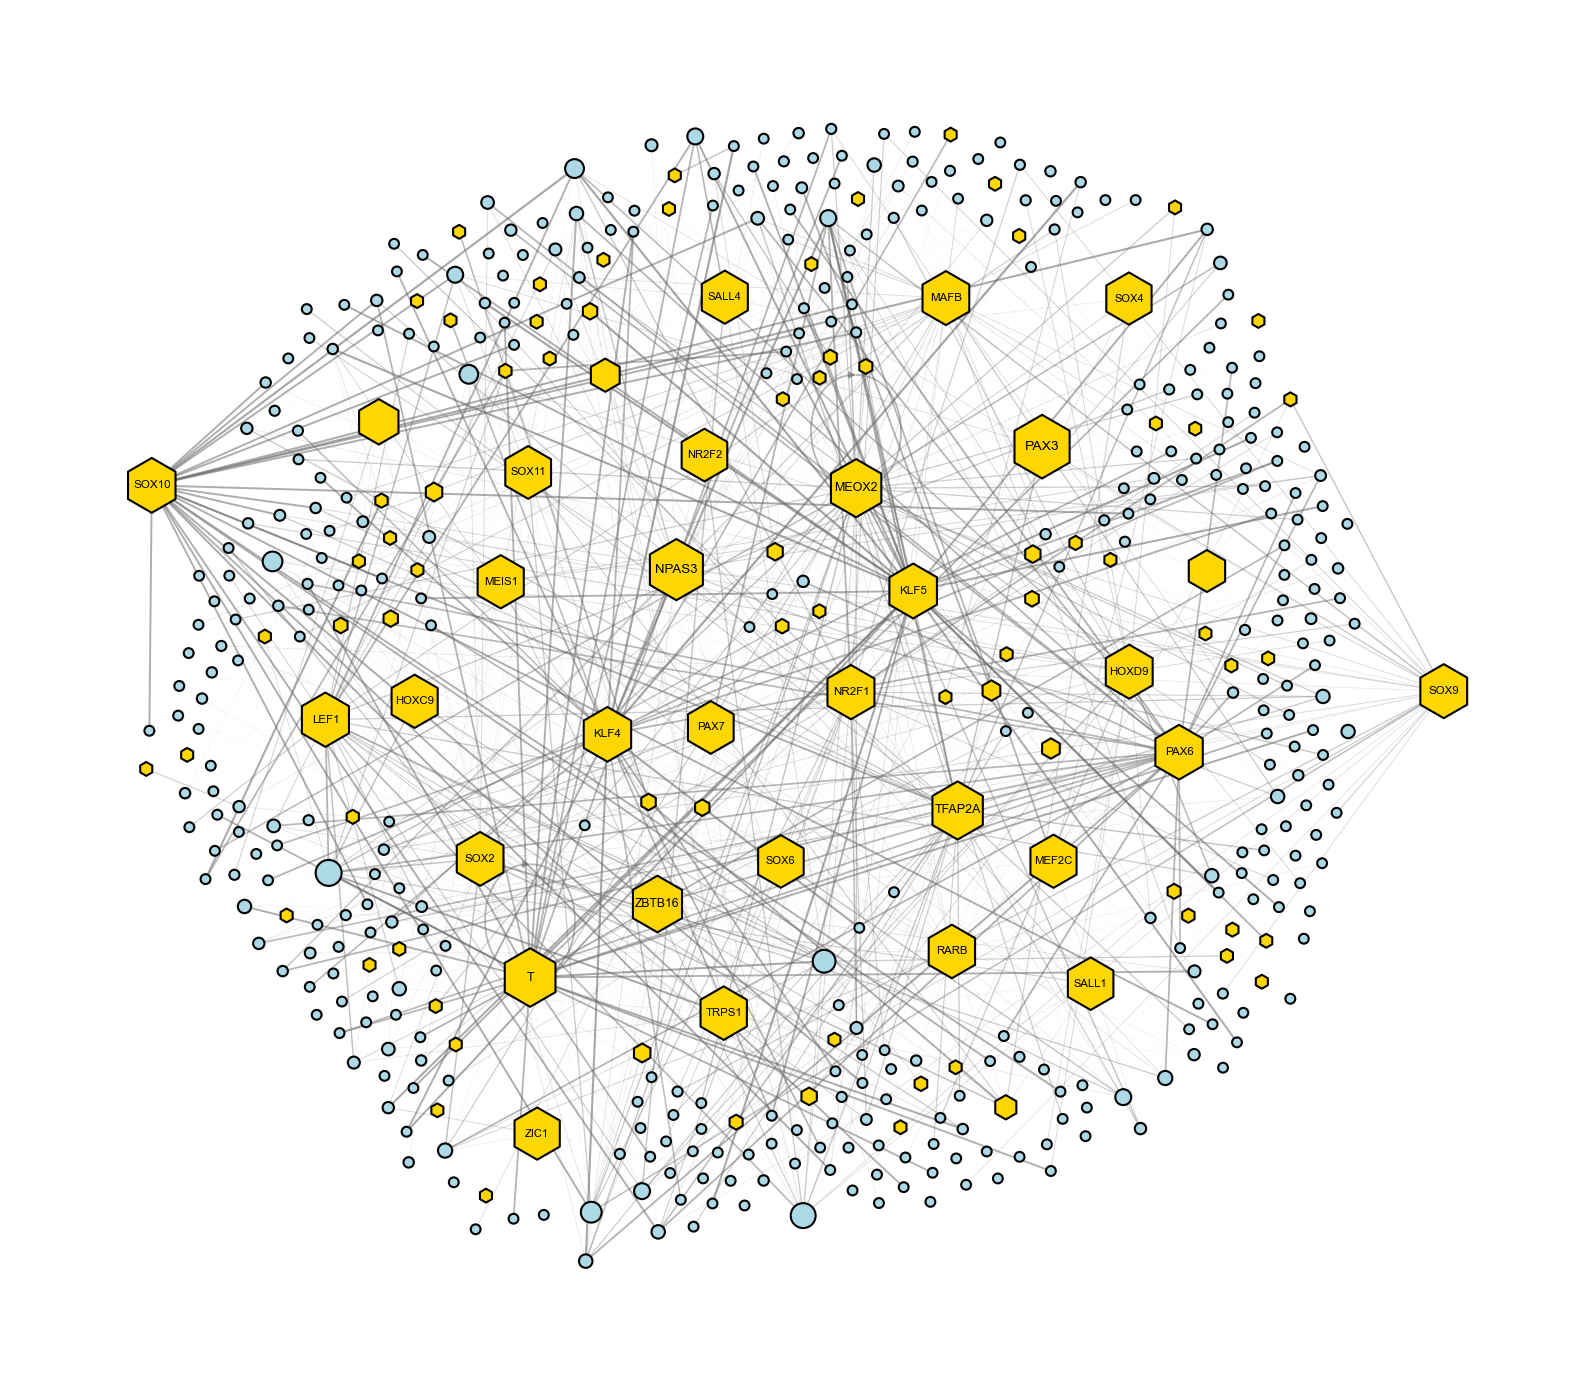

In [25]:
import networkx as nx
from scipy.spatial import cKDTree

def remove_node_collisions_fast(
    pos,
    node_sizes,
    collision_scale=0.018,
    padding=1.2,
    max_iter=50,
    seed=42,
):
    rng = np.random.default_rng(seed)

    nodes = list(pos)

    xy = np.array([
        pos[node]
        for node in nodes
    ], dtype=float)

    sizes = np.array([
        node_sizes[node]
        for node in nodes
    ], dtype=float)

    x_range = np.ptp(xy[:, 0])
    y_range = np.ptp(xy[:, 1])
    layout_scale = max(x_range, y_range, 1e-12)

    radii = (
        np.sqrt(sizes)
        * collision_scale
        * layout_scale
        / 10
    )

    # Largest possible collision distance
    max_search_distance = (
        2 * radii.max() * padding
    )

    for _ in range(max_iter):

        tree = cKDTree(xy)

        candidate_pairs = tree.query_pairs(
            r=max_search_distance
        )

        if not candidate_pairs:
            break

        displacement = np.zeros_like(xy)
        n_collisions = 0

        for i, j in candidate_pairs:

            delta = xy[i] - xy[j]
            distance = np.linalg.norm(delta)

            required_distance = (
                radii[i] + radii[j]
            ) * padding

            if distance >= required_distance:
                continue

            n_collisions += 1

            if distance < 1e-12:
                delta = rng.normal(size=2)
                distance = np.linalg.norm(delta)

            direction = delta / distance

            overlap = (
                required_distance - distance
            )

            push = 0.5 * overlap * direction

            displacement[i] += push
            displacement[j] -= push

        if n_collisions == 0:
            break

        xy += displacement

    return {
        node: xy[i]
        for i, node in enumerate(nodes)
    }


# ============================================================
# Build graph
# ============================================================

G = nx.from_pandas_edgelist(
    filtered_top_tf_prediction_adj_df,
    source="Source",
    target="Target",
    edge_attr=[
        "Score",
        "Score_adjusted",
        "tf_specificity",
    ],
    create_using=nx.DiGraph(),
)


# ============================================================
# Identify TF and TG nodes
# ============================================================

nodes = list(G.nodes())

tf_list = (
    top_tf_prediction_adj_df["Source"]
    .unique()
    .tolist()
)

tg_list = (
    top_tf_prediction_adj_df["Target"]
    .unique()
    .tolist()
)

# Do not count TFs as TGs
tg_list = [
    x
    for x in tg_list
    if x not in tf_list
]

tf_nodes = [
    n
    for n in nodes
    if n in tf_list
]

tg_nodes = [
    n
    for n in nodes
    if n in tg_list
]


# ============================================================
# Calculate score-weighted degrees / node sizes
# ============================================================

# ------------------------------------------------------------
# TF nodes:
# Total weighted degree = sum of Score across both
# incoming and outgoing edges.
# ------------------------------------------------------------

tf_weighted_degrees = np.array([
    G.degree(node, weight="Score")
    for node in tf_nodes
], dtype=float)

tf_degree_min = tf_weighted_degrees.min()
tf_degree_max = tf_weighted_degrees.max()

tf_degree_scaled = (
    (tf_weighted_degrees - tf_degree_min)
    / max(tf_degree_max - tf_degree_min, 1e-12)
)

tf_node_sizes = {
    node: size
    for node, size in zip(
        tf_nodes,
        100 + 2000 * tf_degree_scaled**3.5,
    )
}


# ------------------------------------------------------------
# TG nodes:
# Weighted in-degree = sum of Score across incoming edges.
# ------------------------------------------------------------

tg_weighted_degrees = np.array([
    G.in_degree(node, weight="Score")
    for node in tg_nodes
], dtype=float)

tg_degree_min = tg_weighted_degrees.min()
tg_degree_max = tg_weighted_degrees.max()

tg_degree_scaled = (
    (tg_weighted_degrees - tg_degree_min)
    / max(tg_degree_max - tg_degree_min, 1e-12)
)

tg_node_sizes = {
    node: size
    for node, size in zip(
        tg_nodes,
        50 + 300 * tg_degree_scaled**2,
    )
}


# ------------------------------------------------------------
# Combined dictionary used by collision-removal algorithm
# ------------------------------------------------------------

node_sizes = {
    **tf_node_sizes,
    **tg_node_sizes,
}

# ============================================================
# Initial ForceAtlas2 layout
# ============================================================

# Create stronger layout-specific edge weights
layout_weight_power = 1.5

for u, v, data in G.edges(data=True):
    data["layout_weight"] = (
        data["Score_adjusted"] ** layout_weight_power
    )
    
node_mass = {
    node: 1.0 + G.degree(node, weight="Score")
    for node in G.nodes()
}

force_recalculate = True
pos_path = output_dir / "forceatlas2_pos.pkl"

if os.path.exists(pos_path) and not force_recalculate:
    with open(pos_path, "rb") as f:
        pos = pickle.load(f)
else:
    pos = nx.forceatlas2_layout(
        G,
        max_iter=300,
        scaling_ratio=20.0,
        gravity=1.0,
        weight="layout_weight",
        node_mass=node_mass,
        linlog=True,
        seed=42,
    )

    with open(pos_path, "wb") as f:
        pickle.dump(pos, f)


# ============================================================
# Remove node collisions
# ============================================================

pos = remove_node_collisions_fast(
    pos,
    node_sizes=node_sizes,
    collision_scale=0.018,
    padding=1.10,
    max_iter=50,
)

# ============================================================
# Edge widths and opacity
# ============================================================

scores = np.array([
    G[u][v]["Score"]
    for u, v in G.edges()
])

specificities = np.array([
    G[u][v]["tf_specificity"]
    for u, v in G.edges()
])

score_min, score_max = (
    scores.min(),
    scores.max(),
)

spec_min, spec_max = (
    specificities.min(),
    specificities.max(),
)


score_scaled = (
    (scores - score_min)
    / max(
        score_max - score_min,
        1e-12,
    )
)

spec_scaled = (
    (specificities - spec_min)
    / max(
        spec_max - spec_min,
        1e-12,
    )
)


edge_size = np.clip(
    0.05 + 1.5 * score_scaled**3,
    0.0,
    4.0,
)

edge_opacity = np.clip(
    0 + 0.60 * score_scaled**3,
    0.05,
    0.9,
)


# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(16, 14))


# Draw edges first so nodes appear on top
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=G.edges(),
    width=edge_size,
    edge_color="dimgray",
    alpha=edge_opacity,
    arrows=False,
    # arrowsize=10,
    # arrowstyle="-|>",
)


# ============================================================
# Draw TG nodes
# ============================================================

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=tg_nodes,
    node_color="lightblue",
    node_size=[
        tg_node_sizes[node]
        for node in tg_nodes
    ],
    node_shape="o",
    edgecolors="black",
    linewidths=1.5,
)


# ============================================================
# Draw TF nodes
# ============================================================

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=tf_nodes,
    node_color="gold",
    node_size=[
        tf_node_sizes[node]
        for node in tf_nodes
    ],
    node_shape="h",
    edgecolors="black",
    linewidths=1.5,
)


# ============================================================
# Label largest TF nodes
# ============================================================

# Get out-degree for each TF
tf_out_degrees = pd.Series({
    node: G.out_degree(node)
    for node in tf_nodes
})

# 75th percentile of TF out-degree
out_degree_threshold = tf_out_degrees.quantile(0.75)

# Label every TF at or above that threshold
largest_tf_nodes = [
    node
    for node in tf_nodes
    if G.out_degree(node) >= out_degree_threshold
]

print(f"75th percentile out-degree threshold: {out_degree_threshold}")
print(f"Number of TFs labeled: {len(largest_tf_nodes)}")
print(f"Largest TF nodes: {largest_tf_nodes}")

tf_labels = {
    node: node
    for node in largest_tf_nodes
}


# Scale label font size based on TF node size
labeled_node_sizes = np.array([
    tf_node_sizes[node]
    for node in largest_tf_nodes
], dtype=float)

label_size_min = labeled_node_sizes.min()
label_size_max = labeled_node_sizes.max()

label_size_scaled = (
    (labeled_node_sizes - label_size_min)
    / max(label_size_max - label_size_min, 1e-12)
)

tf_font_sizes = {
    node: font_size
    for node, font_size in zip(
        largest_tf_nodes,
        8 + 2 * label_size_scaled,
    )
}

nx.draw_networkx_labels(
    G,
    pos,
    labels=tf_labels,
    font_size=tf_font_sizes,
    font_weight="bold",
    font_color="black",
    bbox=dict(
        facecolor="none",
        edgecolor="none",
        alpha=0.7,
        pad=1.5,
    ),
)

plt.axis("off")
plt.tight_layout()
plt.show()

In [26]:
len(largest_tf_nodes)

29

In [27]:
# show genes in largest_tf_nodes that are in each nmp marker group
for gene in largest_tf_nodes:
    print(f"{gene.capitalize()}", end=",")
print("\n")
for group, genes in nmp_marker_groups.items():
    genes_in_group = [gene for gene in genes if gene.upper() in largest_tf_nodes]
    print(f"{group}: {', '.join(genes_in_group)}")

Sox10,Klf5,Tfap2a,Pax6,T,Klf4,Meox2,Nr2f1,Sox9,Hoxd9,Lef1,Mafb,Npas3,Rarb,Trps1,Mef2c,Nr2f2,Zic1,Sox6,Zbtb16,Hoxc9,Pax7,Sall4,Meis1,Sox11,Sox4,Pax3,Sall1,Sox2,

NMP: T, Sox2
Early mesoderm: T, Lef1
Lateral and intermediate mesoderm: T
Early neural: Pax3, T, Sox2
Late neural: Sox2


In [28]:
# # Add community IDs to nodes
# for community_id, community in enumerate(communities):
#     for node in community:
#         G.nodes[node]["community"] = int(community_id)

# Add plotted x/y coordinates
for node, xy in pos.items():
    G.nodes[node]["x"] = float(xy[0])
    G.nodes[node]["y"] = float(xy[1])

# Add node type
for node in tf_nodes:
    G.nodes[node]["node_type"] = "TF"

for node in tg_nodes:
    G.nodes[node]["node_type"] = "TG"

# Export
output_graphml_path = output_dir / "specificity_adjusted_regulatory_network.graphml"

nx.write_graphml(
    G,
    output_graphml_path,
)

print(f"Saved GraphML to: {output_graphml_path}")

Saved GraphML to: /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/TETHER/mouse_development_testing/specificity_adjusted_regulatory_network.graphml


---

## NMP Differentiation-Associated Genes

[Koch, et. al. 2017](https://www.sciencedirect.com/science/article/pii/S153458071730597X?via%3Dihub) performed ChIP-seq for Brachyury and Sox2, mapping the binding sites to their nearest neighbors. They looked at which genes were differentially expressed between 5 clusters from their single-cell RNA-seq data.

They provide their ChIP-seq results with labeled groups under their supplemental information [Table S2](https://ars.els-cdn.com/content/image/1-s2.0-S153458071730597X-mmc3.xlsx)

### Load ChIP-seq for Brachyury and Sox2

In [29]:
chip_dir = output_dir / "ChIP-seq"
sox2_chip_df = pd.read_csv(chip_dir / "Sox2_chipseq_genes.tsv", sep='\t')
t_and_sox2_chip_df = pd.read_csv(chip_dir / "T_and_Sox2_chipseq_genes.tsv", sep='\t')
t_chip_df = pd.read_csv(chip_dir / "T_chipseq_genes.tsv", sep='\t')

# Duplicate the t_and_sox2_chip_df for T and Sox2 separately
t_chip_from_t_and_sox2_df = t_and_sox2_chip_df.copy()
t_chip_from_t_and_sox2_df["Source"] = "T"

sox2_chip_from_t_and_sox2_df = t_and_sox2_chip_df.copy()
sox2_chip_from_t_and_sox2_df["Source"] = "Sox2"

# Add specifier columns, then merge
sox2_chip_df["Source"] = "Sox2"
t_chip_df["Source"] = "T"

full_chip_df = pd.concat([
    sox2_chip_df,
    t_chip_df,
    sox2_chip_from_t_and_sox2_df,
    t_chip_from_t_and_sox2_df,
], ignore_index=True)

full_chip_df = full_chip_df.rename(columns={"Gene": "Target"})[["Source", "Target", "Group_Name"]]

full_chip_df["Source"] = full_chip_df["Source"].str.upper()
full_chip_df["Target"] = full_chip_df["Target"].str.upper()

full_chip_df.to_csv(chip_dir / "NMP_T_and_Sox2_chipseq_data.csv", index=False)

full_chip_df = full_chip_df.replace({"Group_Name": {"Nascent mesoderm": "NMP"}})

full_chip_df

,Source,Target,Group_Name
0,SOX2,1190005I06RIK,NMP
1,SOX2,1300002E11RIK,Late neural
2,SOX2,2810429I04RIK,Late neural
3,SOX2,ABCA2,Early neural
4,SOX2,ACOT1,Late neural
...,...,...,...
1574,T,ZFP169,Late neural
1575,T,ZFP677,NMP
1576,T,ZFPM1,Lateral and intermediate mesoderm
1577,T,ZHX2,Early mesoderm


### Plot FeaturePlots of ChIP-seq genes

We can double-check that the target genes in each lineage specified by the study match our cluster own E8.5_rep1 cluster.

In [30]:
def plot_labeled_developmental_umap(
    ax,
    adata,
    lineage_cols,
    umap_label_offsets,
    lineage_col="developmental_lineage",
):

    umap = adata.obsm["X_umap"]

    # Plot developmental lineages
    for lineage, color in lineage_cols.items():

        mask = (
            adata.obs[lineage_col] == lineage
        ).to_numpy()

        if not mask.any():
            continue

        ax.scatter(
            umap[mask, 0],
            umap[mask, 1],
            s=12,
            alpha=0.7,
            c=color,
            linewidths=0,
        )

    # Add lineage labels
    for lineage, color in lineage_cols.items():

        mask = (
            adata.obs[lineage_col] == lineage
        ).to_numpy()

        if not mask.any():
            continue

        x = np.median(umap[mask, 0])
        y = np.median(umap[mask, 1])

        offset = umap_label_offsets.get(
            lineage,
            (30, 30),
        )

        ax.annotate(
            lineage,
            xy=(x, y),
            xytext=offset,
            textcoords="offset points",
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold",
            color=color,
            arrowprops=dict(
                arrowstyle="-",
                color=color,
                linewidth=1.2,
            ),
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                edgecolor=color,
                alpha=0.9,
            ),
        )

    ax.set_title(
        "Developmental lineages",
        fontsize=12,
        fontweight="bold",
    )

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

In [31]:
# Calculate lineage target-gene scores
lineage_score_names = {}

for lineage, results in full_chip_df.groupby("Group_Name"):

    target_genes = [
        gene.capitalize()
        for gene in results["Target"].unique()
        if gene.capitalize() in rna_dev.var_names
    ]

    if len(target_genes) == 0:
        print(
            f"{lineage}: no genes found in rna_dev.var_names"
        )
        continue

    score_name = (
        lineage
        .replace(" ", "_")
        .replace("-", "_")
        + "_target_score"
    )

    sc.tl.score_genes(
        rna_dev,
        gene_list=target_genes,
        score_name=score_name,
        use_raw=False,
    )

    lineage_score_names[lineage] = score_name

    print(
        f"{lineage}: {len(target_genes)} target genes"
    )

Early mesoderm: 179 target genes
Early neural: 184 target genes


Late neural: 238 target genes
Lateral and intermediate mesoderm: 245 target genes
NMP: 98 target genes


... storing 'developmental_lineage' as categorical


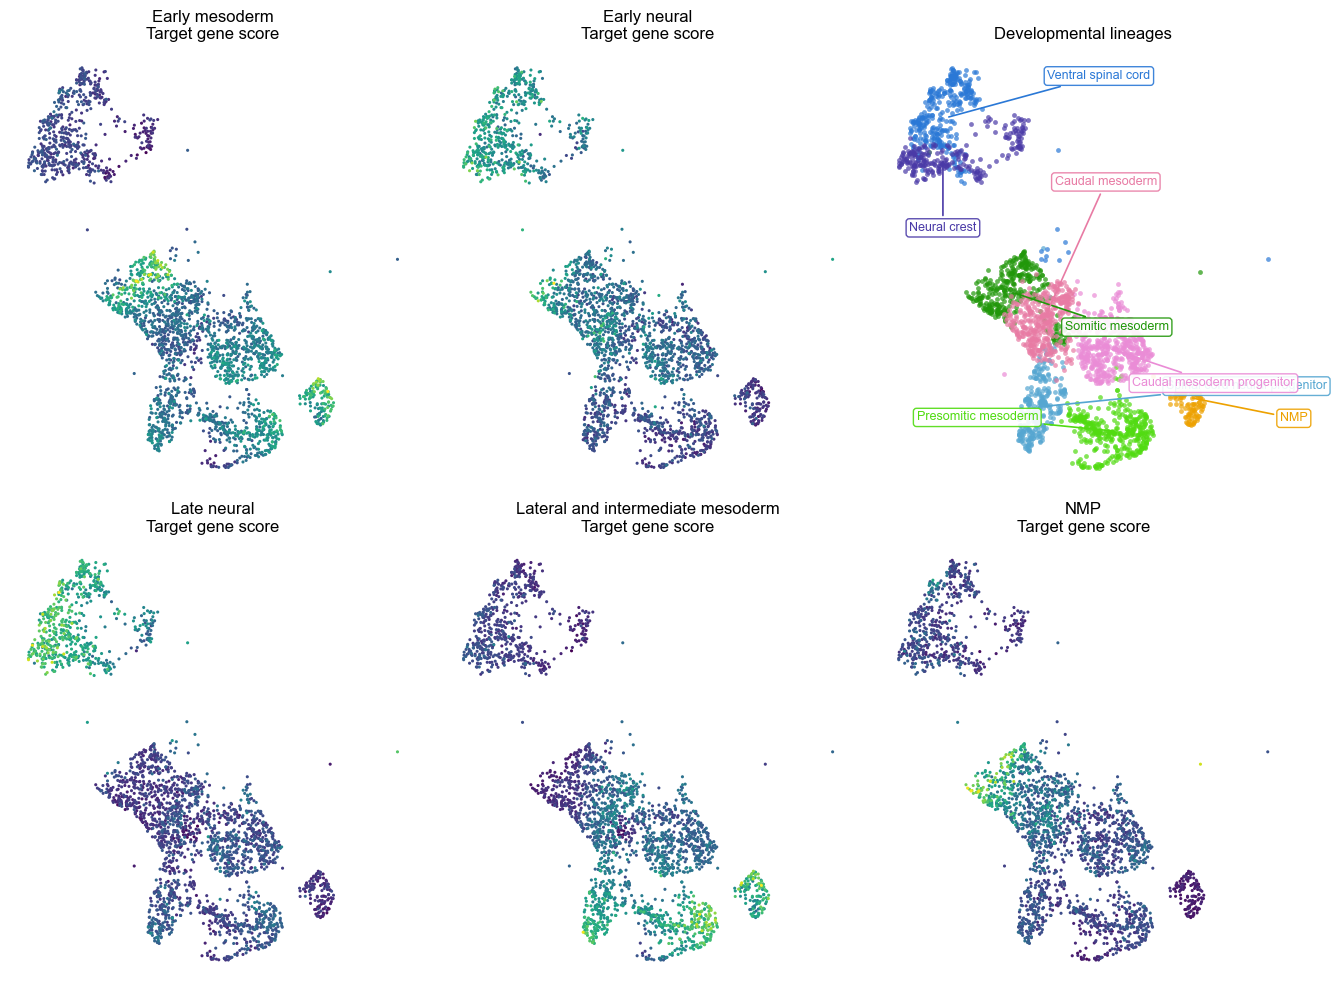

In [32]:
import math

# ============================================================
# Plot: lineage feature plots + one labeled reference UMAP
# ============================================================

n_lineages = len(lineage_score_names)

ncols = 3

# +1 because we also need one panel for the labeled UMAP
n_panels = n_lineages + 1

nrows = math.ceil(n_panels / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(14, 5 * nrows),
    squeeze=False,
)

# Reserve upper-right panel for labeled UMAP
reference_ax = axes[0, 2]

plot_labeled_developmental_umap(
    ax=reference_ax,
    adata=rna_dev,
    lineage_cols=lineage_cols,
    umap_label_offsets=umap_label_offsets,
)

feature_axes = [
    ax
    for row_idx in range(nrows)
    for col_idx, ax in enumerate(axes[row_idx])
    if not (row_idx == 0 and col_idx == 2)
]

# Feature plot of the target genes from each lineage in the ChIP-seq data
for ax, (lineage, score_name) in zip(
    feature_axes,
    lineage_score_names.items(),
):

    sc.pl.umap(
        rna_dev,
        color=score_name,
        cmap="viridis",
        frameon=False,
        size=20,
        ax=ax,
        show=False,
        title=f"{lineage}\nTarget gene score",
        colorbar_loc=None,
    )

# Hide any unused axes
for ax in feature_axes[n_lineages:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

The feature plots of the ChIP-seq target genes per lineage match up nicely with our annotated cell lineages.

### Test if the GRN scores ChIP-seq edges higher than random

We can now use this ChIP-seq data to validate whether the GRN is scoring real TF-TG edges higher than random. We will find the median percentile of TF-TG scores in the ChIP-seq vs random, then use a one-sided Wilcoxon signed-rank test to determine if the GRN ranks ChIP-seq target genes significantly higher than non-ChIP-seq target genes.

In [65]:
import numpy as np
import pandas as pd
from scipy.stats import percentileofscore


def calculate_chipseq_percentiles(
    prediction_df,
    full_chip_df,
):
    """
    Calculate the percentile and rank of curated ChIP-seq edges
    within each TF's predicted target scores.
    """

    # Remove duplicate ChIP-seq edges
    chip_edges = (
        full_chip_df[["Source", "Target"]]
        .drop_duplicates()
        .copy()
    )

    # Group prediction scores once per TF
    tf_target_scores = {
        tf: df[["Target", "Score"]].drop_duplicates("Target")
        for tf, df in prediction_df.groupby("Source", sort=False)
        if tf in set(chip_edges["Source"])
    }

    results = []

    for _, edge in chip_edges.iterrows():
        tf = edge["Source"]
        target = edge["Target"]

        if tf not in tf_target_scores:
            continue

        tf_scores = tf_target_scores[tf]

        target_match = tf_scores["Target"] == target
        if not target_match.any():
            continue

        score = tf_scores.loc[target_match, "Score"].iloc[0]

        percentile = percentileofscore(
            tf_scores["Score"],
            score,
            kind="mean",
        )

        rank = int(
            (tf_scores["Score"] > score).sum() + 1
        )

        results.append({
            "Source": tf,
            "Target": target,
            "Score": score,
            "percentile": percentile,
            "rank": rank,
            "n_candidate_targets": len(tf_scores),
        })

    curated_results_df = (
        pd.DataFrame(results)
        .sort_values("percentile", ascending=False)
        .reset_index(drop=True)
    )

    return curated_results_df

def empirical_chipseq_enrichment_test(
    prediction_df,
    curated_results_df,
    n_perm=99999,
    seed=42,
):
    """
    Test whether known ChIP-seq targets rank higher than random targets
    for the same TF.

    Null:
        For each TF, randomly choose the same number of targets as the
        number of observed ChIP-seq targets for that TF.

    Statistic:
        Median across TFs of each TF's median target-score percentile.

    Returns
    -------
    observed_stat : float
        Observed median TF-level percentile.

    empirical_p : float
        One-sided empirical p-value.

    null_stats : np.ndarray
        Null distribution of the statistic.

    tf_results : pd.DataFrame
        Per-TF observed statistics.
    """

    rng = np.random.default_rng(seed)

    # --------------------------------------------------
    # Precompute percentile for every predicted target
    # within each TF
    # --------------------------------------------------

    tf_data = {}

    for tf, observed_df in curated_results_df.groupby("Source"):

        pred = (
            prediction_df.loc[
                prediction_df["Source"] == tf,
                ["Target", "Score"],
            ]
            .drop_duplicates("Target")
            .copy()
        )

        if pred.empty:
            continue

        # Convert the score distribution to percentile ranks.
        #
        # rank(pct=True) gives values in (0, 1].
        # Multiplying by 100 gives percentile-like values.
        #
        # method="average" handles ties.
        pred["percentile"] = (
            pred["Score"]
            .rank(method="average", pct=True)
            * 100
        )

        observed_targets = set(observed_df["Target"])

        observed_mask = pred["Target"].isin(observed_targets)

        n_observed = observed_mask.sum()

        if n_observed == 0:
            continue

        percentiles = pred["percentile"].to_numpy()

        observed_percentiles = pred.loc[
            observed_mask,
            "percentile",
        ].to_numpy()

        tf_data[tf] = {
            "all_percentiles": percentiles,
            "observed_percentiles": observed_percentiles,
            "n_observed": n_observed,
        }

    # --------------------------------------------------
    # Observed statistic
    # --------------------------------------------------

    tf_observed_stats = {
        tf: np.median(data["observed_percentiles"])
        for tf, data in tf_data.items()
    }

    observed_stat = np.median(
        list(tf_observed_stats.values())
    )

    # --------------------------------------------------
    # Permutation null
    # --------------------------------------------------

    null_stats = np.empty(n_perm)

    for perm_i in range(n_perm):

        random_tf_stats = []

        for tf, data in tf_data.items():

            random_percentiles = rng.choice(
                data["all_percentiles"],
                size=data["n_observed"],
                replace=False,
            )

            random_tf_stats.append(
                np.median(random_percentiles)
            )

        null_stats[perm_i] = np.median(
            random_tf_stats
        )

    # --------------------------------------------------
    # One-sided empirical p-value:
    #
    # H1 = ChIP targets have HIGHER percentiles
    # --------------------------------------------------

    empirical_p = (
        np.sum(null_stats >= observed_stat) + 1
    ) / (n_perm + 1)

    # --------------------------------------------------
    # Per-TF summary
    # --------------------------------------------------

    tf_results = pd.DataFrame({
        "Source": list(tf_observed_stats.keys()),
        "median_chip_percentile": list(tf_observed_stats.values()),
        "n_chip_targets": [
            tf_data[tf]["n_observed"]
            for tf in tf_observed_stats
        ],
        "n_candidate_targets": [
            len(tf_data[tf]["all_percentiles"])
            for tf in tf_observed_stats
        ],
    })

    return (
        observed_stat,
        empirical_p,
        null_stats,
        tf_results,
    )
    
curated_results_df = calculate_chipseq_percentiles(
    prediction_df=prediction_df,
    full_chip_df=full_chip_df,
)

(
    observed_stat,
    empirical_p,
    null_stats,
    tf_results,
) = empirical_chipseq_enrichment_test(
    prediction_df=prediction_df,
    curated_results_df=curated_results_df,
    n_perm=9999,
    seed=42,
)

print(
    f"Observed median TF-level ChIP percentile: "
    f"{observed_stat:.2f}"
)

print(
    f"Null median: "
    f"{np.median(null_stats):.2f}"
)

print(
    f"Empirical one-sided p-value: "
    f"{empirical_p:.4g}"
)

Observed median TF-level ChIP percentile: 76.51
Null median: 49.98
Empirical one-sided p-value: 0.0001


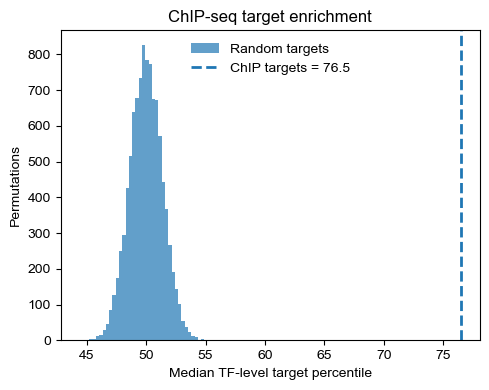

In [67]:
fig, ax = plt.subplots(figsize=(5, 4))

ax.hist(
    null_stats,
    bins=40,
    alpha=0.7,
    label="Random targets",
)

ax.axvline(
    observed_stat,
    linestyle="--",
    linewidth=2,
    label=f"ChIP targets = {observed_stat:.1f}",
)

ax.set(
    xlabel="Median TF-level target percentile",
    ylabel="Permutations",
    title="ChIP-seq target enrichment",
)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

We can also see if the predictions would be different depending on the cell lineage

In [73]:
lineage_results = {}

for lineage in full_chip_df["Group_Name"].unique():
    print(f"\n===== {lineage} =====")

    lineage_df = full_chip_df[
        full_chip_df["Group_Name"] == lineage
    ]

    lineage_results_df = calculate_chipseq_percentiles(
        prediction_df=prediction_df,
        full_chip_df=lineage_df,
    )

    (
        lineage_observed_stat,
        lineage_empirical_p,
        lineage_null_stats,
        lineage_tf_results,
    ) = empirical_chipseq_enrichment_test(
        prediction_df=prediction_df,
        curated_results_df=lineage_results_df,
        n_perm=9999,
        seed=42,
    )

    lineage_results[lineage] = {
        "median_percentile": lineage_observed_stat,
        "random_percentile": np.median(lineage_null_stats),
        "empirical_p": lineage_empirical_p,
    }

    print(f"Observed median TF-level percentile: {lineage_observed_stat:.2f}")
    print(f"Random median TF-level percentile:   {np.median(lineage_null_stats):.2f}")
    print(f"Empirical p-value:                    {lineage_empirical_p:.4g}")


===== NMP =====
Observed median TF-level percentile: 65.49
Random median TF-level percentile:   50.00
Empirical p-value:                    0.0002

===== Late neural =====
Observed median TF-level percentile: 78.90
Random median TF-level percentile:   50.06
Empirical p-value:                    0.0001

===== Early neural =====
Observed median TF-level percentile: 74.85
Random median TF-level percentile:   50.02
Empirical p-value:                    0.0001

===== Lateral and intermediate mesoderm =====
Observed median TF-level percentile: 76.20
Random median TF-level percentile:   50.03
Empirical p-value:                    0.0001

===== Early mesoderm =====
Observed median TF-level percentile: 77.78
Random median TF-level percentile:   50.06
Empirical p-value:                    0.0001


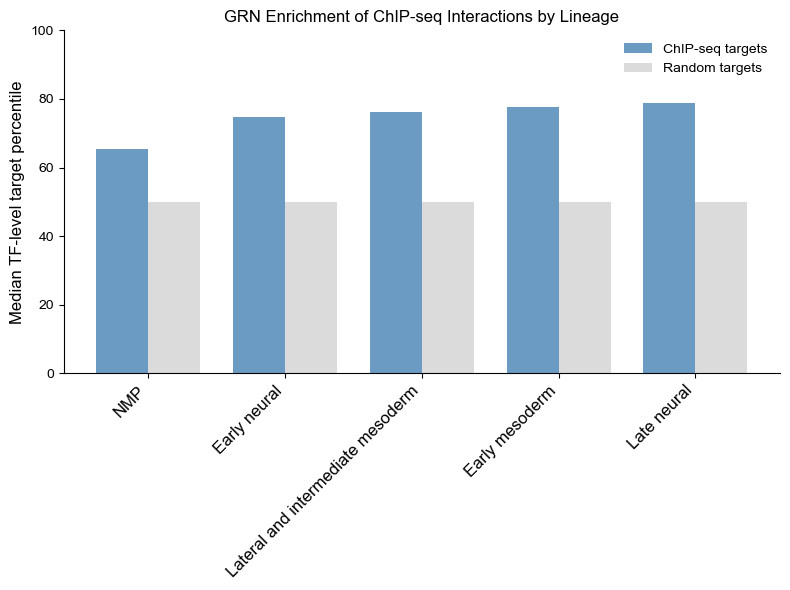

In [ ]:
lineages = sorted(
    lineage_results,
    key=lambda lineage: lineage_results[lineage]["median_percentile"],
)

observed = np.array([
    lineage_results[lineage]["median_percentile"]
    for lineage in lineages
])

random = np.array([
    lineage_results[lineage]["random_percentile"]
    for lineage in lineages
])

p_values = np.array([
    lineage_results[lineage]["empirical_p"]
    for lineage in lineages
])

fig, ax = plt.subplots(figsize=(8, 6))

x = np.arange(len(lineages))
width = 0.38

ax.bar(
    x - width / 2,
    observed,
    width=width,
    color="steelblue",
    alpha=0.8,
    label="ChIP-seq targets",
)

ax.bar(
    x + width / 2,
    random,
    width=width,
    color="lightgray",
    alpha=0.8,
    label="Random targets",
)

ax.set_xticks(x)
ax.set_xticklabels(
    lineages,
    rotation=45,
    ha="right",
    fontsize=12,
)

ax.set_ylabel("Median TF-level edge score percentile", fontsize=12)
ax.set_title("GRN Enrichment of ChIP-seq Interactions by Lineage")
ax.legend(frameon=False)

ax.spines[["top", "right"]].set_visible(False)

plt.ylim(0, 100)

plt.tight_layout()
plt.show()

In all cell lineages, the GRN scores TF-TG pairs that are in the ChIP-seq data significantly higher than TF-TG pairs that are NOT in the ChIP-seq data. The nascent mesoderm (Group I from the paper) had the lowest median percentile of curated edges. This group contains genes expressed in T<sup>+</sup>/Sox2<sup>+</sup> (NMP) cells, but which are downregulated in Sox2<sup>+</sup> (neural) and T<sup>+</sup> (mesoderm) cells. The lineages with the highest median percentile of curated edges were the late neural and the lateral and intermediate mesoderm lineages. These results show that our method assigns significantly higher scores to real TF-TG regulatory relationships compared to random, with improved performance in highly-differentiated cell lineages compared to early intermediate cell lineages.

### AUPRC: ChIP-seq edges vs. GRN

Let's test the GRN's AUPRC for the ChIP-seq edges. We will use a 1:10 True:False edge ratio by randomly sampling 10 edges from the GRN that are not in the ChIP-seq edges.

Positives: 1235 / candidate universe: 34718


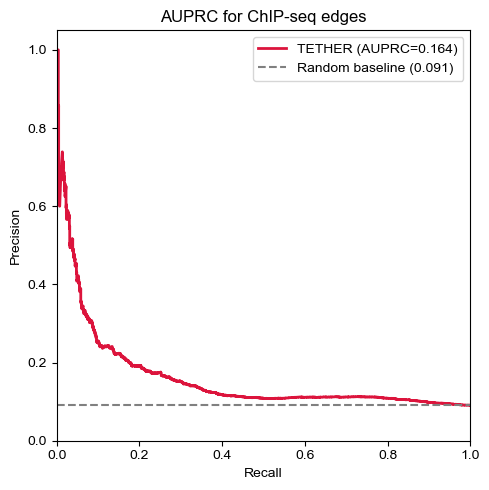

AUPRC = 0.164, baseline = 0.091, lift = 1.80x
Early precision (top 10%): 0.186, lift = 2.05x


In [77]:
from sklearn.metrics import average_precision_score, precision_recall_curve

# Filter predictions to only include sources present in the curated ChIP-seq data
candidate_universe = prediction_df[
    prediction_df["Source"].isin(full_chip_df["Source"])
].copy()

positive_pairs = set(zip(full_chip_df["Source"], full_chip_df["Target"]))
candidate_universe["is_curated"] = [
    (s, t) in positive_pairs
    for s, t in zip(candidate_universe["Source"], candidate_universe["Target"])
]

n_pos = int(candidate_universe["is_curated"].sum())
print(f"Positives: {n_pos} / candidate universe: {len(candidate_universe)}")

# Sample negatives at 10x positives
neg_pool = candidate_universe[~candidate_universe["is_curated"]]
sampled_negs = neg_pool.sample(
    n=min(len(neg_pool), n_pos * 10),
    random_state=42,
)

eval_df = pd.concat([
    candidate_universe[candidate_universe["is_curated"]],
    sampled_negs,
]).reset_index(drop=True)

def plot_auprc_curves(eval_df):
    auprc = average_precision_score(eval_df["is_curated"], eval_df["Score"])
    baseline = eval_df["is_curated"].mean()
    precision, recall, _ = precision_recall_curve(eval_df["is_curated"], eval_df["Score"])

    top_10_percent_edges = eval_df["Score"].quantile(0.90)
    early_precision = eval_df[eval_df["Score"] >= top_10_percent_edges]["is_curated"].mean()

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(recall, precision, color="crimson", linewidth=2, label=f"TETHER (AUPRC={auprc:.3f})")
    ax.axhline(baseline, color="gray", linestyle="--", label=f"Random baseline ({baseline:.3f})")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("AUPRC for ChIP-seq edges")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    print(f"AUPRC = {auprc:.3f}, baseline = {baseline:.3f}, lift = {auprc / baseline:.2f}x")
    print(f"Early precision (top 10%): {early_precision:.3f}, lift = {early_precision / baseline:.2f}x")
    
plot_auprc_curves(eval_df)

TETHER shows a modest increase over random when predicting ChIP-seq edges. The highest scored edges are enriched for True edges at low recall.

### AUPRC Lift

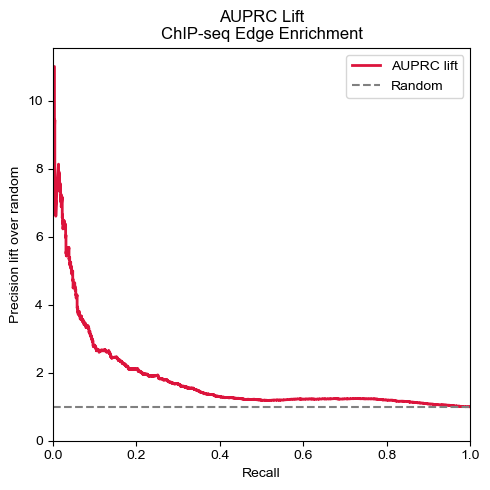

In [78]:
def plot_auprc_lift(eval_df):
    """
    Plot the precision lift curve for the curated ChIP-seq edges.

    Parameters:
    - eval_df: DataFrame containing 'is_curated' and 'Score' columns for evaluation.
    """

    # Calculate PR curve
    auprc = average_precision_score(
        eval_df["is_curated"],
        eval_df["Score"],
    )

    baseline = eval_df["is_curated"].mean()

    precision, recall, thresholds = precision_recall_curve(
        eval_df["is_curated"],
        eval_df["Score"],
    )

    # Convert precision to precision lift
    precision_lift = precision / baseline

    auprc_lift = auprc / baseline

    # Top 10% prediction threshold
    top_10_threshold = eval_df["Score"].quantile(0.90)

    threshold_idx = np.argmin(
        np.abs(thresholds - top_10_threshold)
    )

    top10_recall = recall[threshold_idx]
    top10_precision = precision[threshold_idx]

    top10_precision_lift = (
        top10_precision / baseline
    )

    # Plot precision lift vs recall
    fig, ax = plt.subplots(
        figsize=(5, 5)
    )

    ax.plot(
        recall,
        precision_lift,
        color="crimson",
        linewidth=2,
        label=(
            f"AUPRC lift"
        ),
    )

    # Random expectation
    ax.axhline(
        1,
        color="gray",
        linestyle="--",
        label="Random",
    )

    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision lift over random")

    ax.set_title(
        "AUPRC Lift\nChIP-seq Edge Enrichment"
    )

    ax.set_xlim(0, 1)

    ax.set_ylim(
        0,
        max(precision_lift) * 1.05,
    )

    ax.legend(
        loc="upper right",
    )

    plt.tight_layout()
    plt.show()
    
plot_auprc_lift(eval_df)

The highest-scoring edges are 2-6x more likely to contain True edges. As this model was trained using hepatocyes, this reuslt demonstrates that TETHER is able to generalize to unseen cell lineages to recover experimentally-validated TF-TG regulatory relationships.

### Boostrap AUPRC scores

We can make sure that this AUPRC score is representative by using bootstrapping resampling of the positive and negative edges to get a distribution of AUPRC values for different True/False edge samplings.

In [79]:
def bootstrap_chip_auprc(
    candidate_universe,
    score_col="Score",
    label_col="is_curated",
    negative_ratio=10,
    n_negative_repeats=100,
    n_bootstraps=100,
    random_seed=42,
):
    """
    Estimate uncertainty in ChIP-seq validation metrics using:

    1. repeated negative sampling
    2. stratified bootstrap resampling within each sampled dataset

    Returns
    -------
    bootstrap_df : pd.DataFrame
        Metrics from every bootstrap replicate.

    summary_df : pd.DataFrame
        Mean/median and 95% percentile CI for each metric.
    """

    rng = np.random.default_rng(random_seed)

    positive_df = candidate_universe[
        candidate_universe[label_col]
    ].copy()

    negative_pool = candidate_universe[
        ~candidate_universe[label_col]
    ].copy()

    n_pos = len(positive_df)

    if n_pos == 0:
        raise ValueError("No positive ChIP-seq edges found.")

    n_neg = min(
        len(negative_pool),
        n_pos * negative_ratio,
    )

    results = []

    # Repeatedly choose different negative sets
    for neg_repeat in range(n_negative_repeats):

        neg_seed = int(
            rng.integers(0, 2**32 - 1)
        )

        sampled_negatives = negative_pool.sample(
            n=n_neg,
            replace=False,
            random_state=neg_seed,
        )

        # Bootstrap positives and negatives separately
        for bootstrap_id in range(n_bootstraps):

            pos_seed = int(
                rng.integers(0, 2**32 - 1)
            )

            neg_boot_seed = int(
                rng.integers(0, 2**32 - 1)
            )

            boot_pos = positive_df.sample(
                n=n_pos,
                replace=True,
                random_state=pos_seed,
            )

            boot_neg = sampled_negatives.sample(
                n=n_neg,
                replace=True,
                random_state=neg_boot_seed,
            )

            boot_df = pd.concat(
                [boot_pos, boot_neg],
                ignore_index=True,
            )

            y_true = (
                boot_df[label_col]
                .astype(int)
                .to_numpy()
            )

            y_score = (
                boot_df[score_col]
                .to_numpy()
            )

            # AUPRC / average precision
            auprc = average_precision_score(
                y_true,
                y_score,
            )

            baseline = y_true.mean()

            lift = (
                auprc / baseline
                if baseline > 0
                else np.nan
            )

            # Precision among top 10% of predictions
            top_10_threshold = np.quantile(
                y_score,
                0.90,
            )

            top_10_mask = (
                y_score >= top_10_threshold
            )

            top_10_precision = (
                y_true[top_10_mask].mean()
            )

            top_10_lift = (
                top_10_precision / baseline
                if baseline > 0
                else np.nan
            )

            results.append({
                "negative_repeat": neg_repeat,
                "bootstrap_id": bootstrap_id,
                "auprc": auprc,
                "baseline": baseline,
                "lift": lift,
                "top_10_precision": top_10_precision,
                "top_10_lift": top_10_lift,
            })

    bootstrap_df = pd.DataFrame(results)

    # Summarize bootstrap distributions
    metrics = [
        "auprc",
        "baseline",
        "lift",
        "top_10_precision",
        "top_10_lift",
    ]

    summary = []

    for metric in metrics:

        values = bootstrap_df[metric].dropna()

        summary.append({
            "metric": metric,
            "mean": values.mean(),
            "median": values.median(),
            "ci_lower": values.quantile(0.025),
            "ci_upper": values.quantile(0.975),
            "std": values.std(),
        })

    summary_df = pd.DataFrame(summary)

    return bootstrap_df, summary_df

bootstrap_df, bootstrap_summary_df = bootstrap_chip_auprc(
    candidate_universe,
    score_col="Score",
    label_col="is_curated",
    negative_ratio=10,
    n_negative_repeats=100,
    n_bootstraps=100,
    random_seed=42,
)

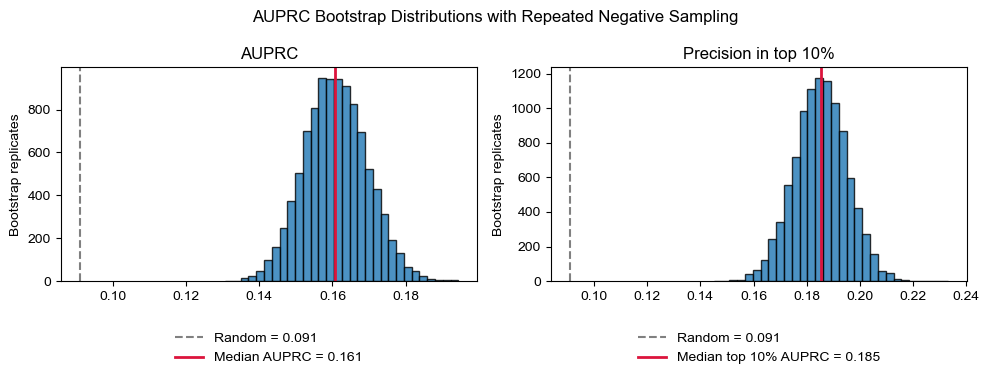

In [80]:
def plot_bootstrap_auprc_distributions(
    bootstrap_df,
    bootstrap_summary_df,
    baseline,
):
    """
    Plot the bootstrap distributions of AUPRC and top 10% precision.

    Parameters
    ----------
    bootstrap_df : pd.DataFrame
        DataFrame containing bootstrap replicate metrics.

    bootstrap_summary_df : pd.DataFrame
        Summary statistics for each metric.

    baseline : float
        Baseline precision (random expectation).
    """
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(10, 4),
    )

    # ============================================================
    # AUPRC
    # ============================================================

    median = (
        bootstrap_summary_df
        .set_index("metric")
        .loc["auprc", "median"]
    )

    axes[0].hist(
        bootstrap_df["auprc"],
        bins=30,
        edgecolor="black",
        alpha=0.8,
    )

    axes[0].axvline(
        baseline,
        linestyle="--",
        color="gray",
        label=f"Random = {baseline:.3f}"
    )

    axes[0].axvline(
        median,
        color="crimson",
        linewidth=2,
        label=f"Median AUPRC = {median:.3f}"
    )

    axes[0].set_title("AUPRC")
    axes[0].set_ylabel("Bootstrap replicates")

    axes[0].legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=1,
        frameon=False,
    )


    # ============================================================
    # Top 10% precision
    # ============================================================

    median_top_10_precision = (
        bootstrap_summary_df
        .set_index("metric")
        .loc["top_10_precision", "median"]
    )

    axes[1].hist(
        bootstrap_df["top_10_precision"],
        bins=30,
        edgecolor="black",
        alpha=0.8,
    )

    axes[1].axvline(
        baseline,
        linestyle="--",
        color="gray",
        label=f"Random = {baseline:.3f}"
    )

    axes[1].axvline(
        median_top_10_precision,
        color="crimson",
        linewidth=2,
        label=f"Median top 10% AUPRC = {median_top_10_precision:.3f}"
    )

    axes[1].legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=1,
        frameon=False,
    )

    axes[1].set_title("Precision in top 10%")
    axes[1].set_ylabel("Bootstrap replicates")


    # ============================================================
    # Figure title
    # ============================================================

    fig.suptitle(
        "AUPRC Bootstrap Distributions with Repeated Negative Sampling"
    )

    plt.tight_layout()
    plt.show()
    
plot_bootstrap_auprc_distributions(
    bootstrap_df,
    bootstrap_summary_df,
    baseline=bootstrap_summary_df.set_index("metric").loc["baseline", "mean"],
)

---

## Testing GRN predictions against Brachyury KO

The mouse hepatocyte 1 TF-TG model was used to generate GRNs for an E8.5 mouse embryo with Brachyury knocked out via CRISPR/Cas9 targeting exon 3 of the Brachyury gene and a wild-type control (Cas9 but no guide RNA).

In [ ]:
T_KO_GRN_file = RESULT_DIR / "full_test_grns" / "hepatocytes_1_model_vs_E8.5_CRISPR_T_KO_full_grn.tsv"
T_WT_GRN_file = RESULT_DIR / "full_test_grns" / "hepatocytes_1_model_vs_E8.5_CRISPR_T_WT_full_grn.tsv"

T_KO_GRN_df = pd.read_csv(T_KO_GRN_file, sep="\t")
T_WT_GRN_df = pd.read_csv(T_WT_GRN_file, sep="\t")

